In [252]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from particle import Particle

In [253]:
file = uproot.open("../full_Hsphere/MuravesSim_Data_20260310_113155.root")
#print(file.keys())

gen_tree = file["PrimaryGenData"]
gen_data = gen_tree.arrays(["Event", "GenPartID", "GenPartPDG", "GenPartE", "GenPartTheta", "GenPartPhi"], 
                            aliases = {"event": "Event",
                                       "track_id": "nGenPartID",
                                       "pdg":    "GenPartPDG",
                                        "energy": "GenPartE",
                                        "theta":  "GenPartTheta",
                                        "phi":    "GenPartPhi",
                                        },                           
                            library="ak")

hit_tree = file["HitData"]
hit_data = hit_tree.arrays(["Event", "NScintHit", "ScintHitParentID", "ScintHitE", 
                        "ScintHitPosX", "ScintHitPosY", "ScintHitPosZ", 
                        "ScintHitStation", "ScintHitModule", "ScintHitBar", 
                        "ScintHitPDG", "ScintHitTrackID"],
                        aliases={
                            "event":      "Event",
                            "n_hits":     "NScintHit",
                            "parent_id":  "ScintHitParentID",
                            "hit_energy":     "ScintHitE",
                            "x":          "ScintHitPosX",
                            "y":          "ScintHitPosY",
                            "z":          "ScintHitPosZ",
                            "station":    "ScintHitStation",
                            "module":     "ScintHitModule",
                            "bar":        "ScintHitBar",
                            "pdg":        "ScintHitPDG",
                            "track_id":   "ScintHitTrackID",
                        },                          
                        library="ak")

In [254]:
hit_event_ids = hit_data["Event"]
#_, counts = np.unique(ak.to_numpy(hit_event_ids), return_counts=True) # number of hits per event

counts = pd.Series(hit_event_ids).value_counts().sort_index().values # number of hits per event

# make jagged array (unflatten)
hit_jagged = ak.zip({
    "hit_energy":   ak.unflatten(hit_data["ScintHitE"],      counts),
    "x":        ak.unflatten(hit_data["ScintHitPosX"],   counts),
    "y":        ak.unflatten(hit_data["ScintHitPosY"],   counts),
    "z":        ak.unflatten(hit_data["ScintHitPosZ"],   counts),
    "station":  ak.unflatten(hit_data["ScintHitStation"],counts),
    "module":   ak.unflatten(hit_data["ScintHitModule"], counts),
    "bar":      ak.unflatten(hit_data["ScintHitBar"],    counts),
    "pdg":      ak.unflatten(hit_data["ScintHitPDG"],    counts),
    "track_id": ak.unflatten(hit_data["ScintHitTrackID"],counts),
    "parent_id":ak.unflatten(hit_data["ScintHitParentID"],counts),
})

In [255]:
# Total energy deposited per event
#edep_per_event = ak.sum(hit_data["ScintHitE"], axis=1)
edep_per_event = ak.sum(hit_jagged["hit_energy"], axis=1)

In [256]:
hit_df = hit_tree.arrays(
    ["Event", "ScintHitBar", "ScintHitModule", "ScintHitStation", "ScintHitE", "ScintHitPDG", "ScintHitTrackID", "ScintHitParentID"],
    library="pd"   # load as pandas dataframe
)
hit_df.columns = ["event", "bar", "module", "station", "energy", "pdg", "track_id", "parent_id"]

count    1729.000000
mean       17.078658
std       114.263238
min         6.000000
25%        10.000000
50%        13.000000
75%        16.000000
max      4752.000000
dtype: float64

Top 10 events by hit count:
event
56688    4752
93847     172
17875     143
51720     100
63064      99
9333       79
192        62
19028      61
10105      59
41257      55
dtype: int64


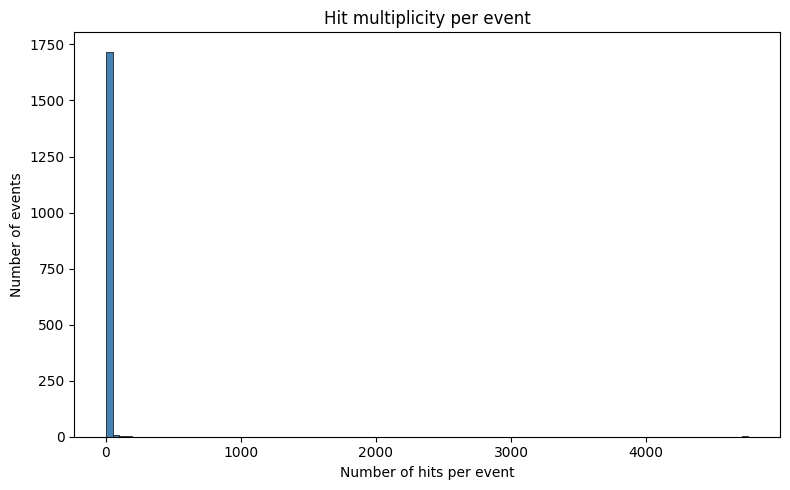

In [257]:
# Hits per event --> to filter bad event
hits_per_event = hit_df.groupby("event").size()

print(hits_per_event.describe())
print("\nTop 10 events by hit count:")
print(hits_per_event.nlargest(10))

plt.figure(figsize=(8, 5))
plt.hist(hits_per_event.values, bins=100, color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Number of hits per event")
plt.ylabel("Number of events")
plt.title("Hit multiplicity per event")
plt.tight_layout()
plt.show()

In [258]:
max_hits = 500  # adjust based on what you see
good_events = hits_per_event[hits_per_event < max_hits].index
hit_df = hit_df[hit_df["event"].isin(good_events)]

print(f"Events before: {hits_per_event.shape[0]}")
print(f"Events after:  {hit_df['event'].nunique()}")

Events before: 1729
Events after:  1728


In [259]:
# Energy per bar per event
edep_bar     = hit_df.groupby(["event", "bar"])["energy"].sum()
edep_bar.columns = ["event", "bar", "edep"]

# Energy per module per event
edep_module  = hit_df.groupby(["event", "module"])["energy"].sum()

# Energy per station per event
edep_station = hit_df.groupby(["event", "station"])["energy"].sum()

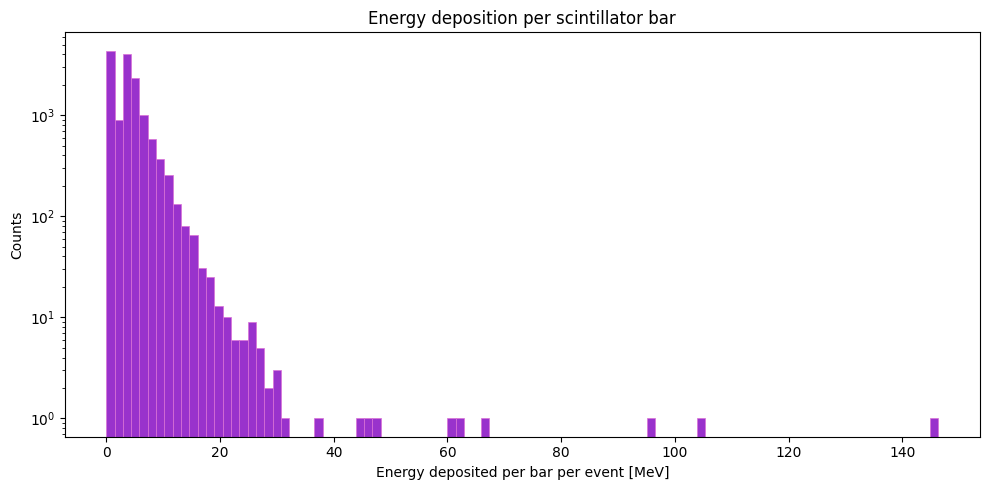

In [260]:
plt.figure(figsize=(10, 5))
plt.hist(edep_bar.values, bins=100, color="darkorchid", edgecolor="orchid", linewidth=0.5)
plt.xlabel("Energy deposited per bar per event [MeV]")
plt.ylabel("Counts")
plt.yscale("log")  # useful if dynamic range is large
plt.title("Energy deposition per scintillator bar")
plt.tight_layout()
plt.show()

In [261]:
# Check which PDG codes are in your data
unique_pdgs = hit_df["pdg"].unique()
print("PDG codes in data:", sorted(unique_pdgs))

for pdg in sorted(unique_pdgs):
    try:
        name = Particle.from_pdgid(pdg).name
    except:
        name = "unknown"
    print(f"PDG {pdg:>8} → {name}")

def pdg_to_name(pdg):
    try:
        return Particle.from_pdgid(pdg).name
    except:
        return f"PDG {pdg}"

PDG codes in data: [np.int32(-211), np.int32(-13), np.int32(-11), np.int32(11), np.int32(13), np.int32(22), np.int32(2112), np.int32(2212), np.int32(1000010020), np.int32(1000020040), np.int32(1000050110), np.int32(1000060120), np.int32(1000060130)]
PDG     -211 → pi-
PDG      -13 → mu+
PDG      -11 → e+
PDG       11 → e-
PDG       13 → mu-
PDG       22 → gamma
PDG     2112 → n
PDG     2212 → p
PDG 1000010020 → D2
PDG 1000020040 → He4
PDG 1000050110 → B11
PDG 1000060120 → C12
PDG 1000060130 → C13


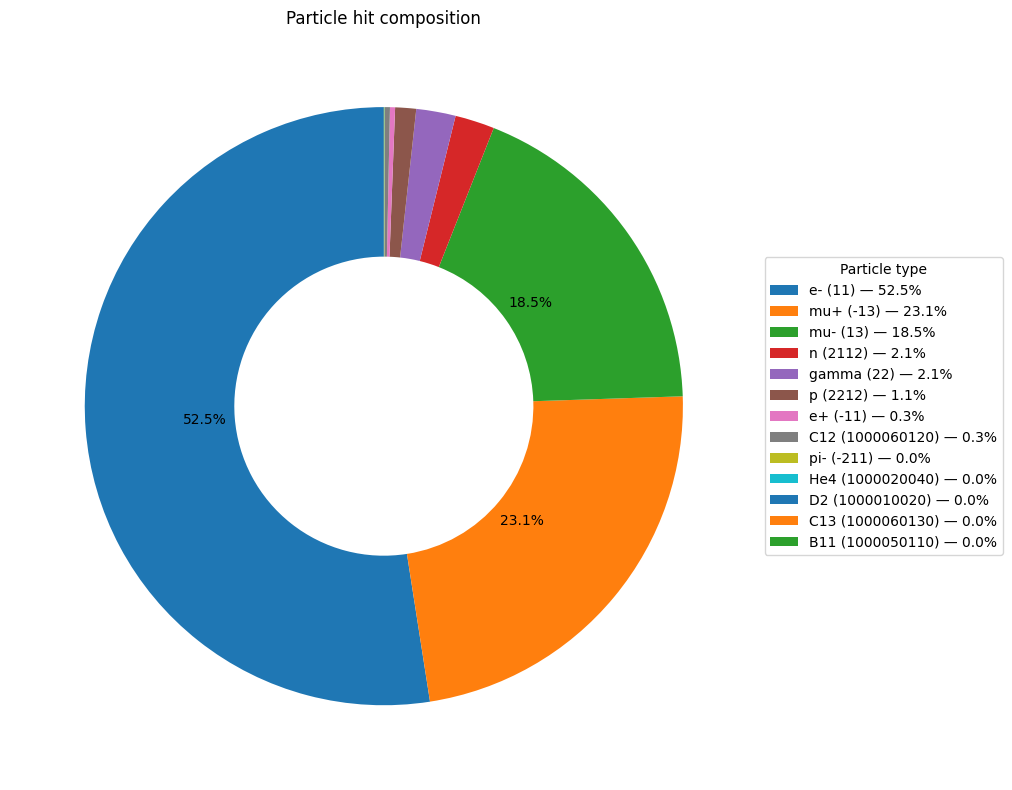

In [262]:
pdg_counts = hit_df["pdg"].value_counts()
pdg_percent = hit_df["pdg"].value_counts(normalize=True) * 100

labels_with_pct = [f"{pdg_to_name(p)} ({p}) — {pct:.1f}%" 
                   for p, pct in zip(pdg_percent.index, pdg_percent.values)]

plt.figure(figsize=(10, 8))
wedges, autotexts, texts = plt.pie(
    pdg_percent.values,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 3 else "",
    startangle=90,
    wedgeprops=dict(width=0.5)
)

plt.legend(wedges, labels_with_pct,
           title="Particle type",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Particle hit composition")
plt.tight_layout()
plt.show()

In [263]:
gen_df = gen_tree.arrays(["Event", "GenPartPhi", "GenPartTheta", "GenPartPDG", "GenPartE"], library="pd")

# Classify forward/backward muons by phi quadrant
gen_df = gen_df.copy()
gen_df["direction"] = np.where(
    (gen_df["GenPartPhi"] > -np.pi/2) & (gen_df["GenPartPhi"] < np.pi/2),
    "forward",
    "backward")

print(gen_df["direction"].value_counts())

direction
forward     988
backward    741
Name: count, dtype: int64


In [264]:
directional_hit_df = hit_df.merge(
    gen_df[["Event", "direction"]],
    left_on="event",
    right_on="Event",
    how="inner"
).drop(columns="Event")

print(directional_hit_df.head())

   event  bar  module  station    energy  pdg  track_id  parent_id direction
0   1395   16       0        2  4.292411  -13         1          0  backward
1   1395    2       1       10  4.211426  -13         1          0  backward
2   1395   20       0        0  4.042369  -13         1          0  backward
3   1395   16       0        8  4.619717  -13         1          0  backward
4   1395   24       0        1  4.112127  -13         1          0  backward


In [265]:
def classify_generation(parent_id):
    if parent_id == 0:
        return "primary"
    elif parent_id == 1:
        return "secondary"
    else:
        return "tertiary+"

hit_df["generation"] = hit_df["parent_id"].map(classify_generation)

In [266]:
hits_forward  = directional_hit_df[directional_hit_df["direction"] == "forward"]
hits_backward = directional_hit_df[directional_hit_df["direction"] == "backward"]

hits_per_bar_forward  = hits_forward.groupby("bar").size()
hits_per_bar_backward = hits_backward.groupby("bar").size()

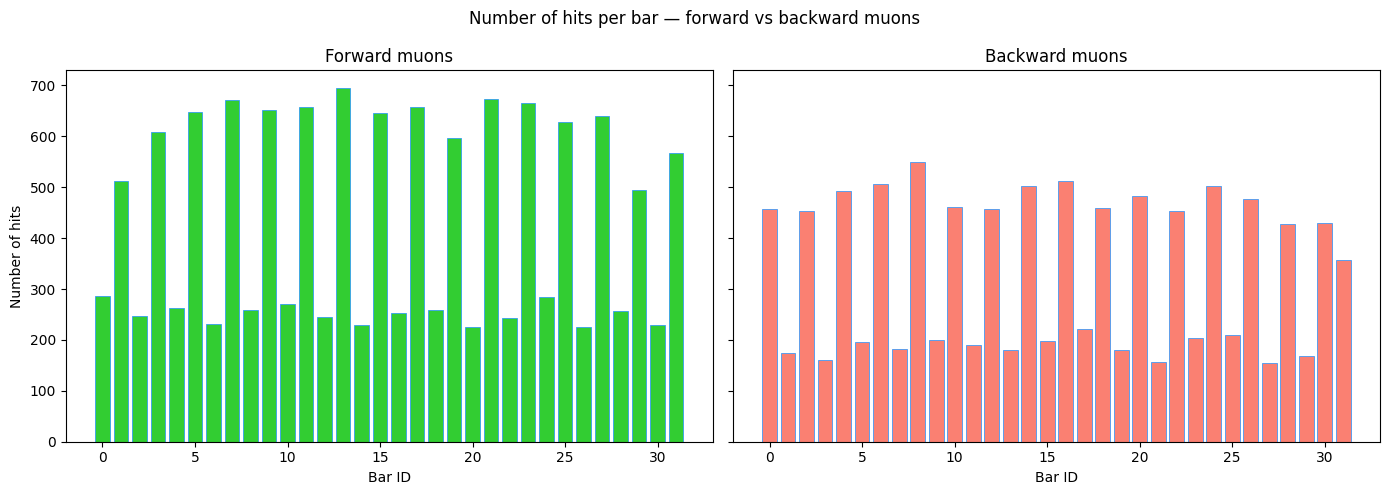

In [267]:
all_bars = np.union1d(hits_per_bar_forward.index, hits_per_bar_backward.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(hits_per_bar_forward.index, hits_per_bar_forward.values, color="limegreen", edgecolor="dodgerblue", linewidth=0.5)
axes[0].set_title("Forward muons")
axes[0].set_xlabel("Bar ID")
axes[0].set_ylabel("Number of hits")

axes[1].bar(hits_per_bar_backward.index, hits_per_bar_backward.values, color="salmon", edgecolor="dodgerblue", linewidth=0.5)
axes[1].set_title("Backward muons")
axes[1].set_xlabel("Bar ID")

plt.suptitle("Number of hits per bar — forward vs backward muons")
plt.tight_layout()
plt.show()

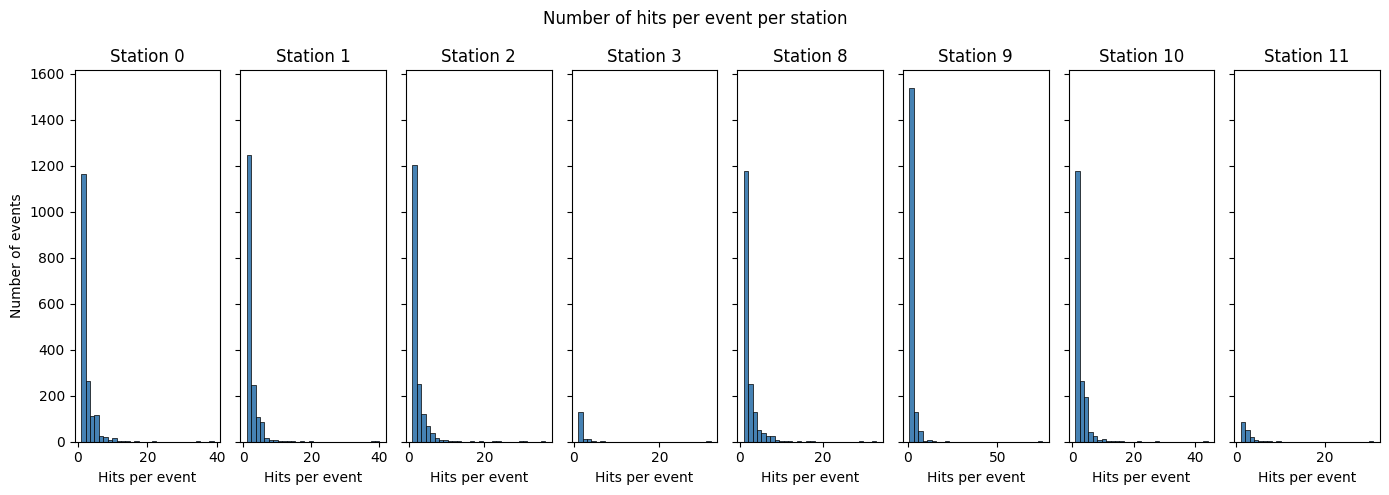

In [268]:
hits_per_event_station = hit_df.groupby(["event", "station"]).size().reset_index(name="nhits")

fig, axes = plt.subplots(1, len(hits_per_event_station["station"].unique()), 
                          figsize=(14, 5), sharey=True)

for ax, (station, group) in zip(axes, hits_per_event_station.groupby("station")):
    ax.hist(group["nhits"], bins=30, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Station {station}")
    ax.set_xlabel("Hits per event")

axes[0].set_ylabel("Number of events")
plt.suptitle("Number of hits per event per station")
plt.tight_layout()
plt.show()

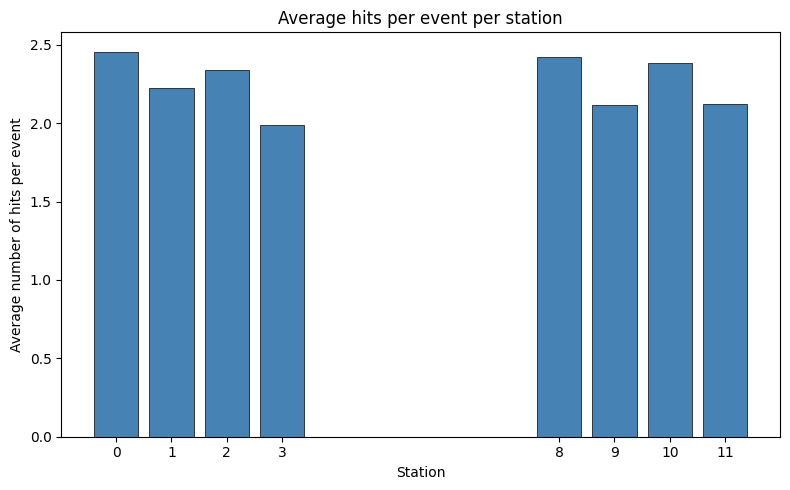

In [269]:
avg_hits_per_station = hit_df.groupby(["event", "station"]).size().groupby("station").mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_hits_per_station.index, avg_hits_per_station.values,
        color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Station")
plt.ylabel("Average number of hits per event")
plt.title("Average hits per event per station")
plt.xticks(avg_hits_per_station.index)
plt.tight_layout()
plt.show()

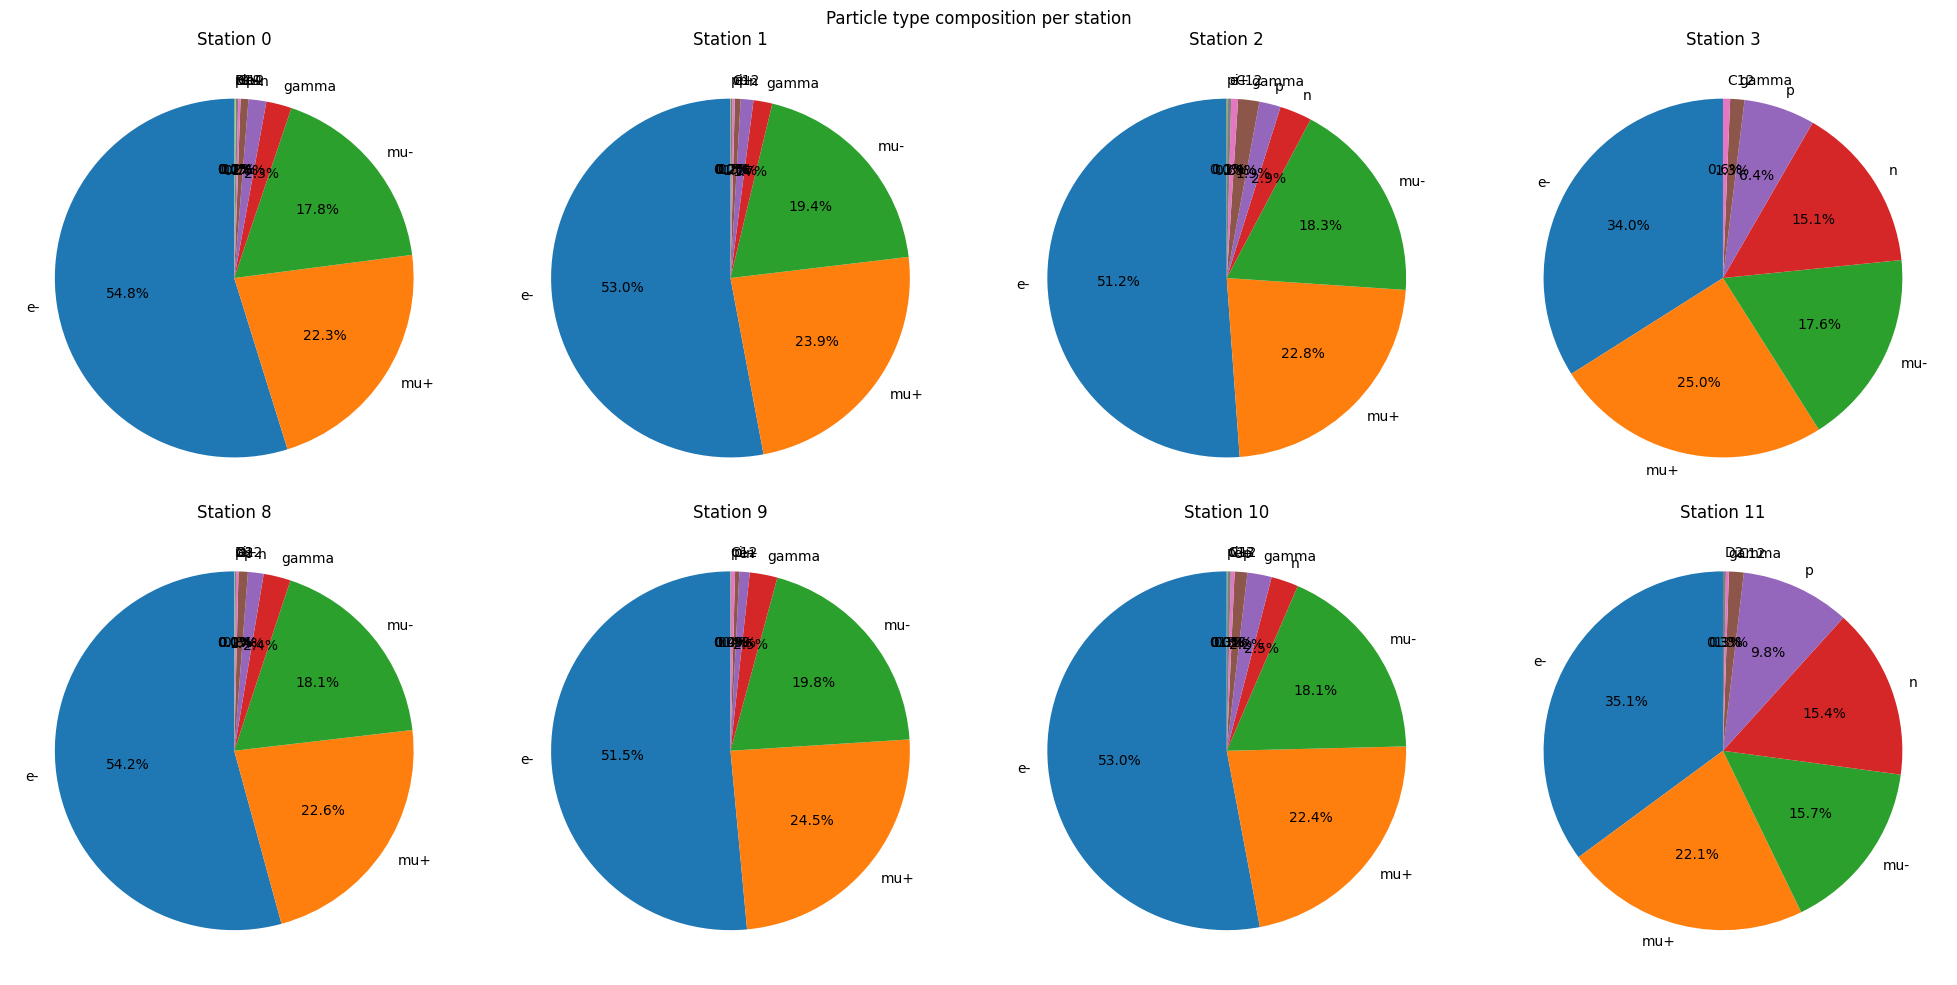

In [270]:
stations = sorted(hit_df["station"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (station, group) in zip(axes, hit_df.groupby("station")):
    pdg_counts = group["pdg"].value_counts()
    labels = [pdg_to_name(p) for p in pdg_counts.index]

    ax.pie(pdg_counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(f"Station {station}")

plt.suptitle("Particle type composition per station")
plt.tight_layout()
plt.show()

count    1712.000000
mean        7.839953
std         7.800558
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max       137.000000
Name: track_id, dtype: float64


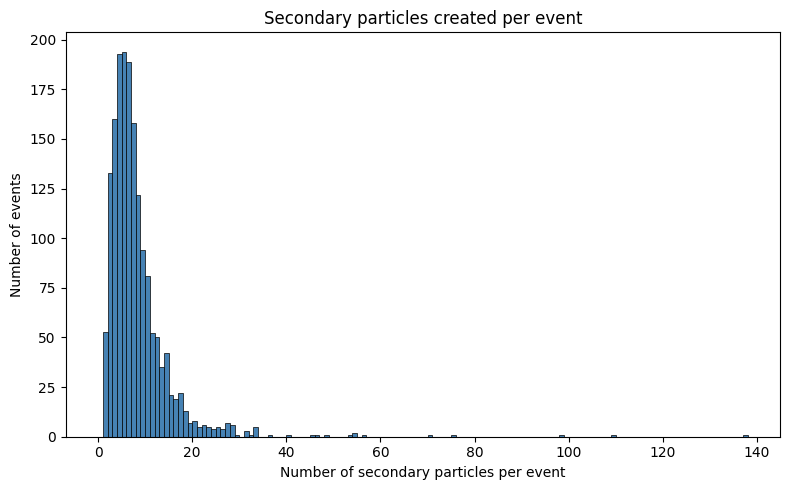

In [271]:
secondaries_per_event = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby("event")["track_id"]
    .nunique()
)

print(secondaries_per_event.describe())

max_val = secondaries_per_event.max()
bins = np.arange(0, max_val + 2, 1)  # [0, 1, 2, ..., max+1]

plt.figure(figsize=(8, 5))
plt.hist(secondaries_per_event.values, bins=bins, color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Number of secondary particles per event")
plt.ylabel("Number of events")
plt.title("Secondary particles created per event")
plt.tight_layout()
plt.show()

Hit composition by generation:
generation
primary      41.54
secondary    37.04
tertiary+    21.42
Name: proportion, dtype: float64


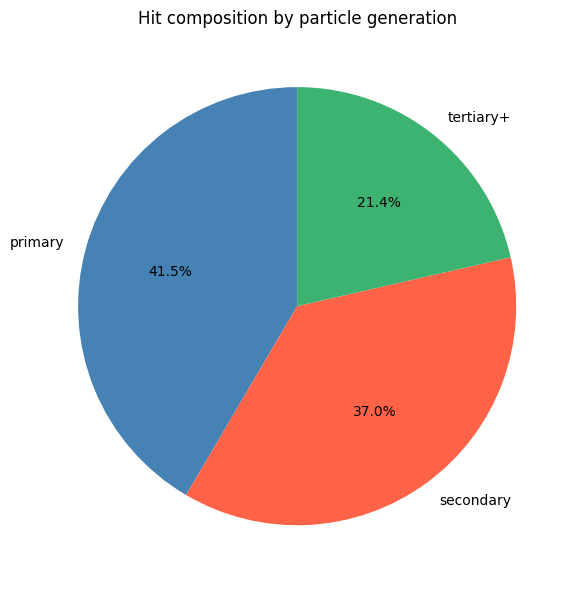

In [272]:
def classify_generation(parent_id):
    if parent_id == 0:
        return "primary"
    elif parent_id == 1:
        return "secondary"
    else:
        return "tertiary+"

hit_df["generation"] = hit_df["parent_id"].map(classify_generation)

# Percentage of hits per generation
gen_counts  = hit_df["generation"].value_counts()
gen_percent = hit_df["generation"].value_counts(normalize=True) * 100

print("Hit composition by generation:")
print(gen_percent.round(2))

# Plot
plt.figure(figsize=(6, 6))
plt.pie(gen_counts.values, labels=gen_counts.index, autopct="%1.1f%%", startangle=90,
        colors=["steelblue", "tomato", "mediumseagreen"])
plt.title("Hit composition by particle generation")
plt.tight_layout()
plt.show()

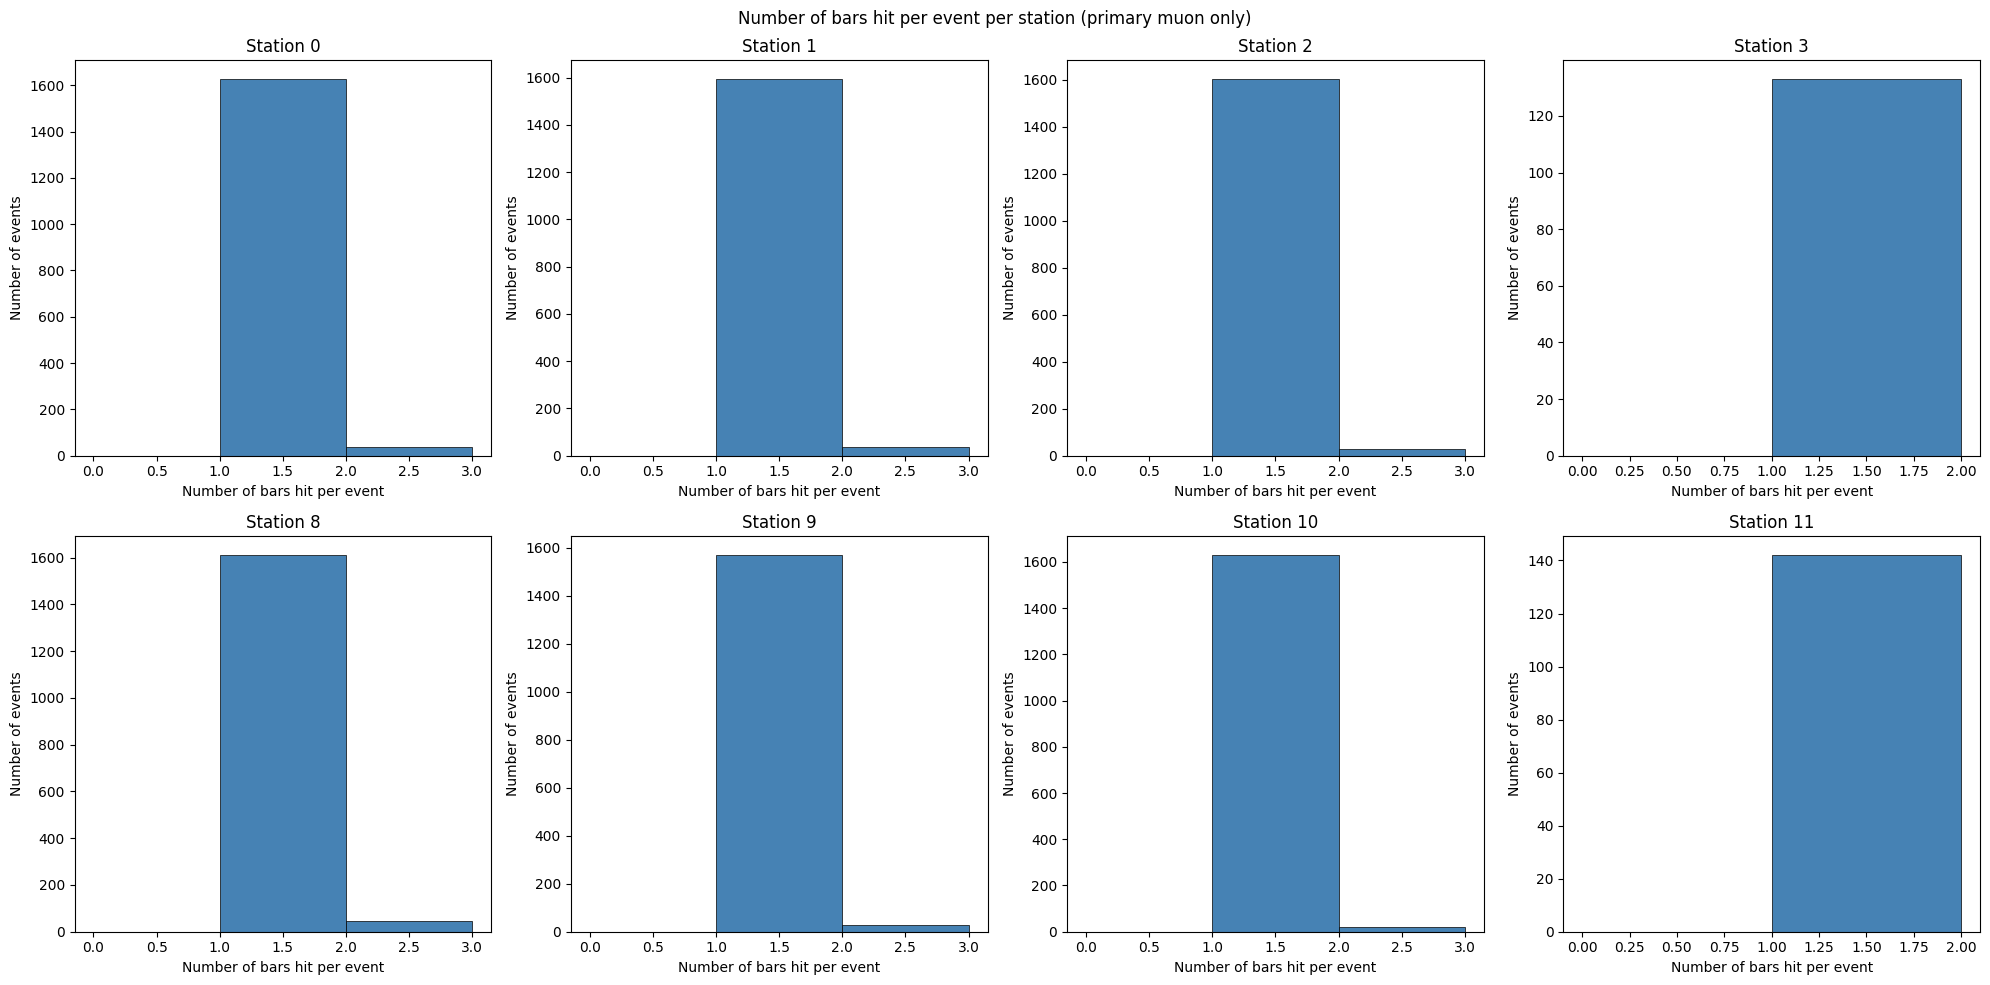

In [273]:
# Filter primary hits only
primary_hits = hit_df[hit_df["parent_id"] == 0]

# Count unique bars hit per event per station
bars_hit_per_event_station = (
    primary_hits
    .groupby(["event", "station"])["bar"]
    .nunique()
    .reset_index(name="nbars")
)

# Plot: one histogram per station
stations = sorted(bars_hit_per_event_station["station"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (station, group) in zip(axes, bars_hit_per_event_station.groupby("station")):
    max_val = group["nbars"].max()
    bins = np.arange(0, max_val + 2, 1)
    ax.hist(group["nbars"], bins=bins, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Station {station}")
    ax.set_xlabel("Number of bars hit per event")
    ax.set_ylabel("Number of events")

for ax in axes[len(stations):]:
    ax.set_visible(False)

plt.suptitle("Number of bars hit per event per station (primary muon only)")
plt.tight_layout()
plt.show()

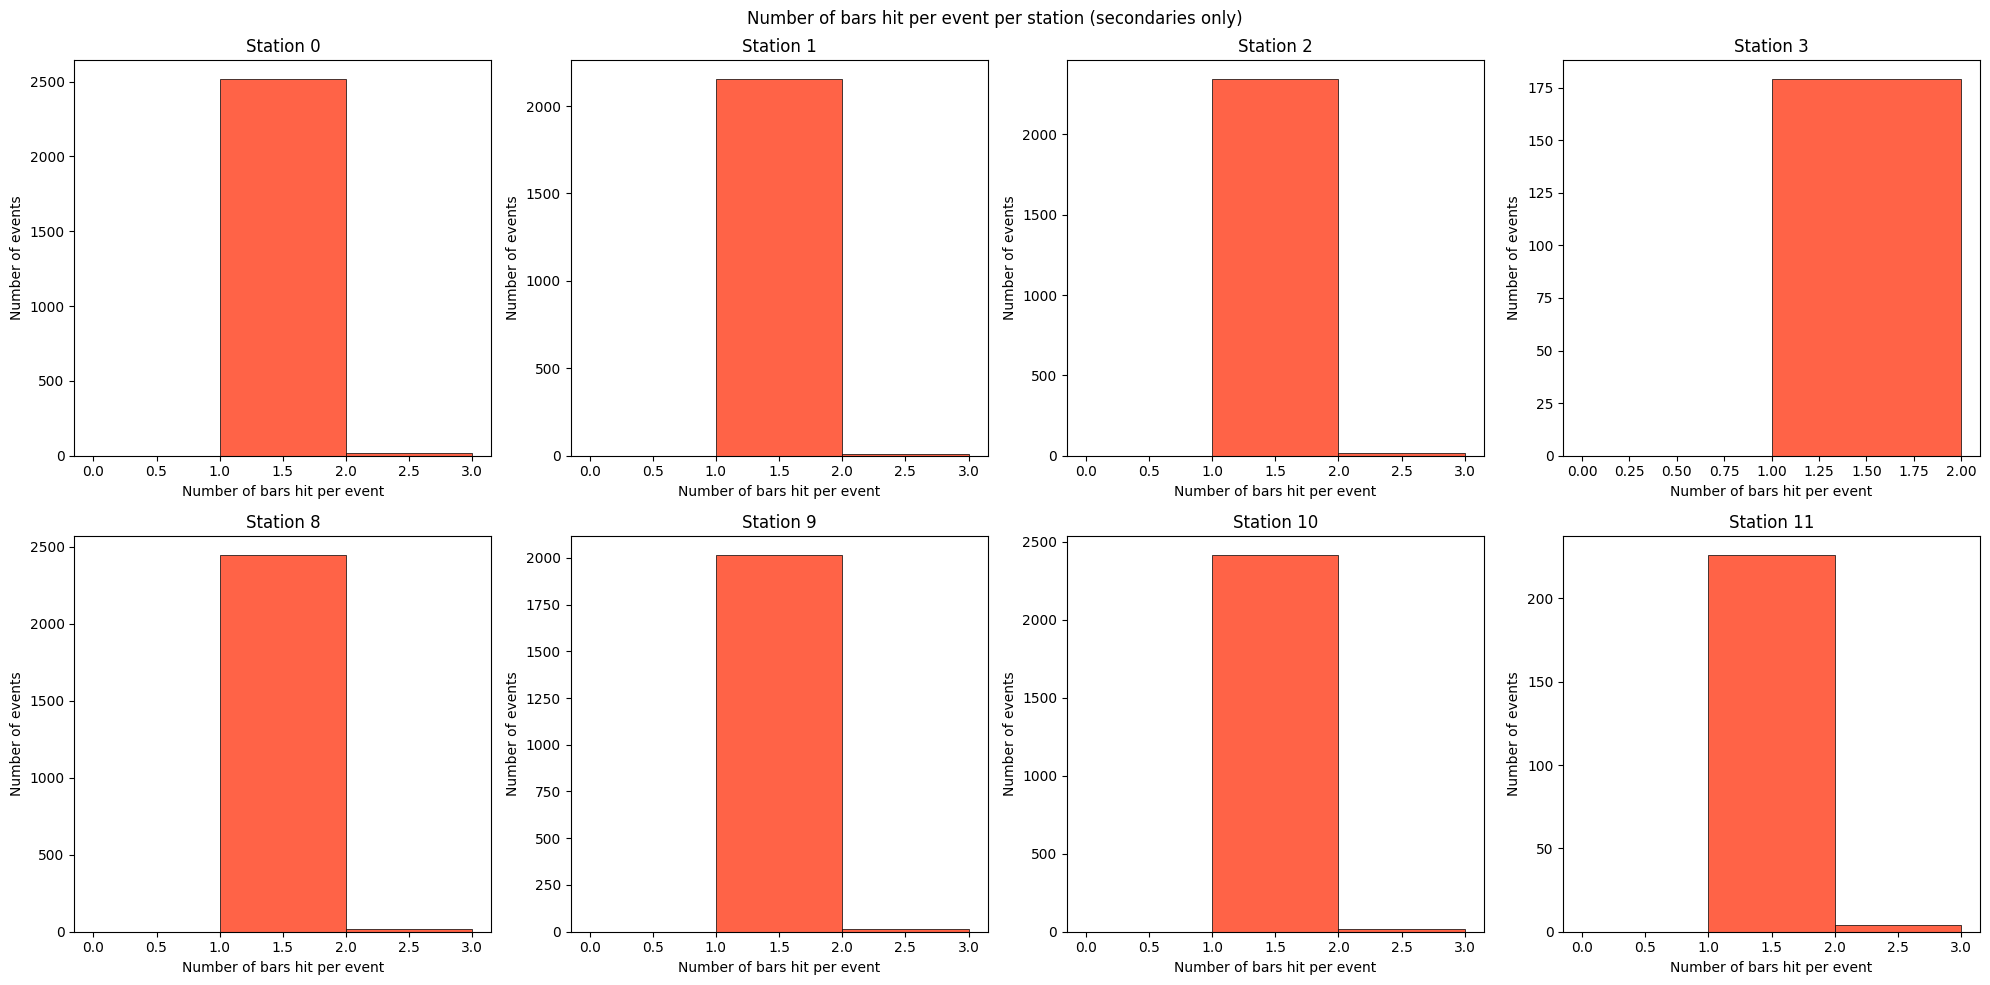

In [274]:
secondary_hits = hit_df[hit_df["parent_id"] > 0]

bars_hit_per_event_station = (
    secondary_hits
    .groupby(["event", "station", "track_id"])["bar"]
    .nunique()
    .reset_index(name="nbars")
)

stations = sorted(bars_hit_per_event_station["station"].unique())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (station, group) in zip(axes, bars_hit_per_event_station.groupby("station")):
    max_val = group["nbars"].max()
    bins = np.arange(0, max_val + 2, 1)
    ax.hist(group["nbars"], bins=bins, color="tomato", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Station {station}")
    ax.set_xlabel("Number of bars hit per event")
    ax.set_ylabel("Number of events")

for ax in axes[len(stations):]:
    ax.set_visible(False)

plt.suptitle("Number of bars hit per event per station (secondaries only)")
plt.tight_layout()
plt.show()

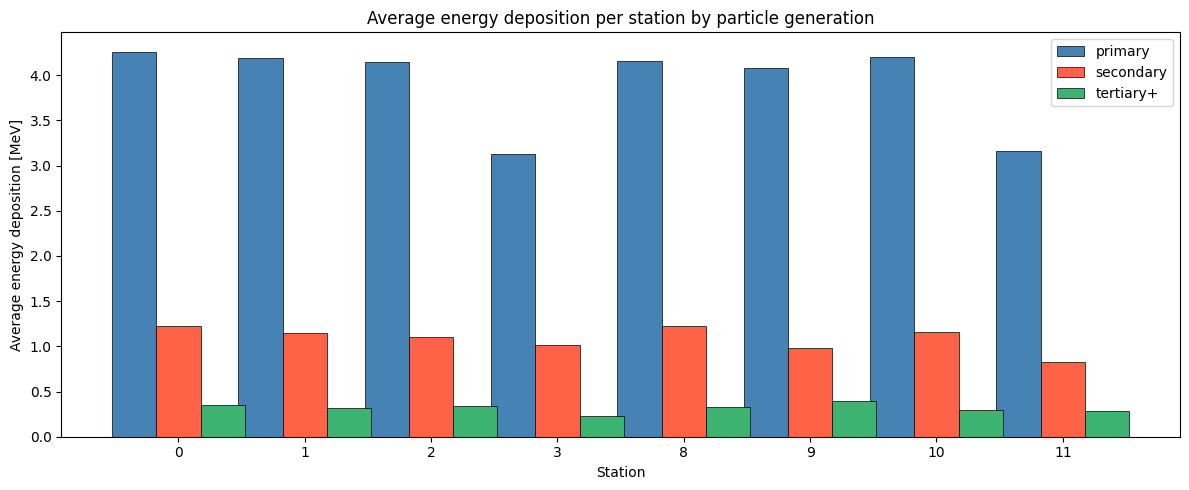

In [275]:
# Average energy deposition per station for primary and secondary hits
edep_by_generation = (
    hit_df.groupby(["generation", "station"])["energy"]
    .mean()
    .reset_index(name="avg_edep")
)

stations = sorted(hit_df["station"].unique())
x = np.arange(len(stations))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

for i, (generation, color) in enumerate(zip(["primary", "secondary", "tertiary+"],
                                             ["steelblue", "tomato", "mediumseagreen"])):
    data = edep_by_generation[edep_by_generation["generation"] == generation]
    ax.bar(x + i * width, data["avg_edep"].values, width,
           label=generation, color=color, edgecolor="black", linewidth=0.5)

ax.set_xlabel("Station")
ax.set_ylabel("Average energy deposition [MeV]")
ax.set_title("Average energy deposition per station by particle generation")
ax.set_xticks(x + width)
ax.set_xticklabels(stations)
ax.legend()
plt.tight_layout()
plt.show()

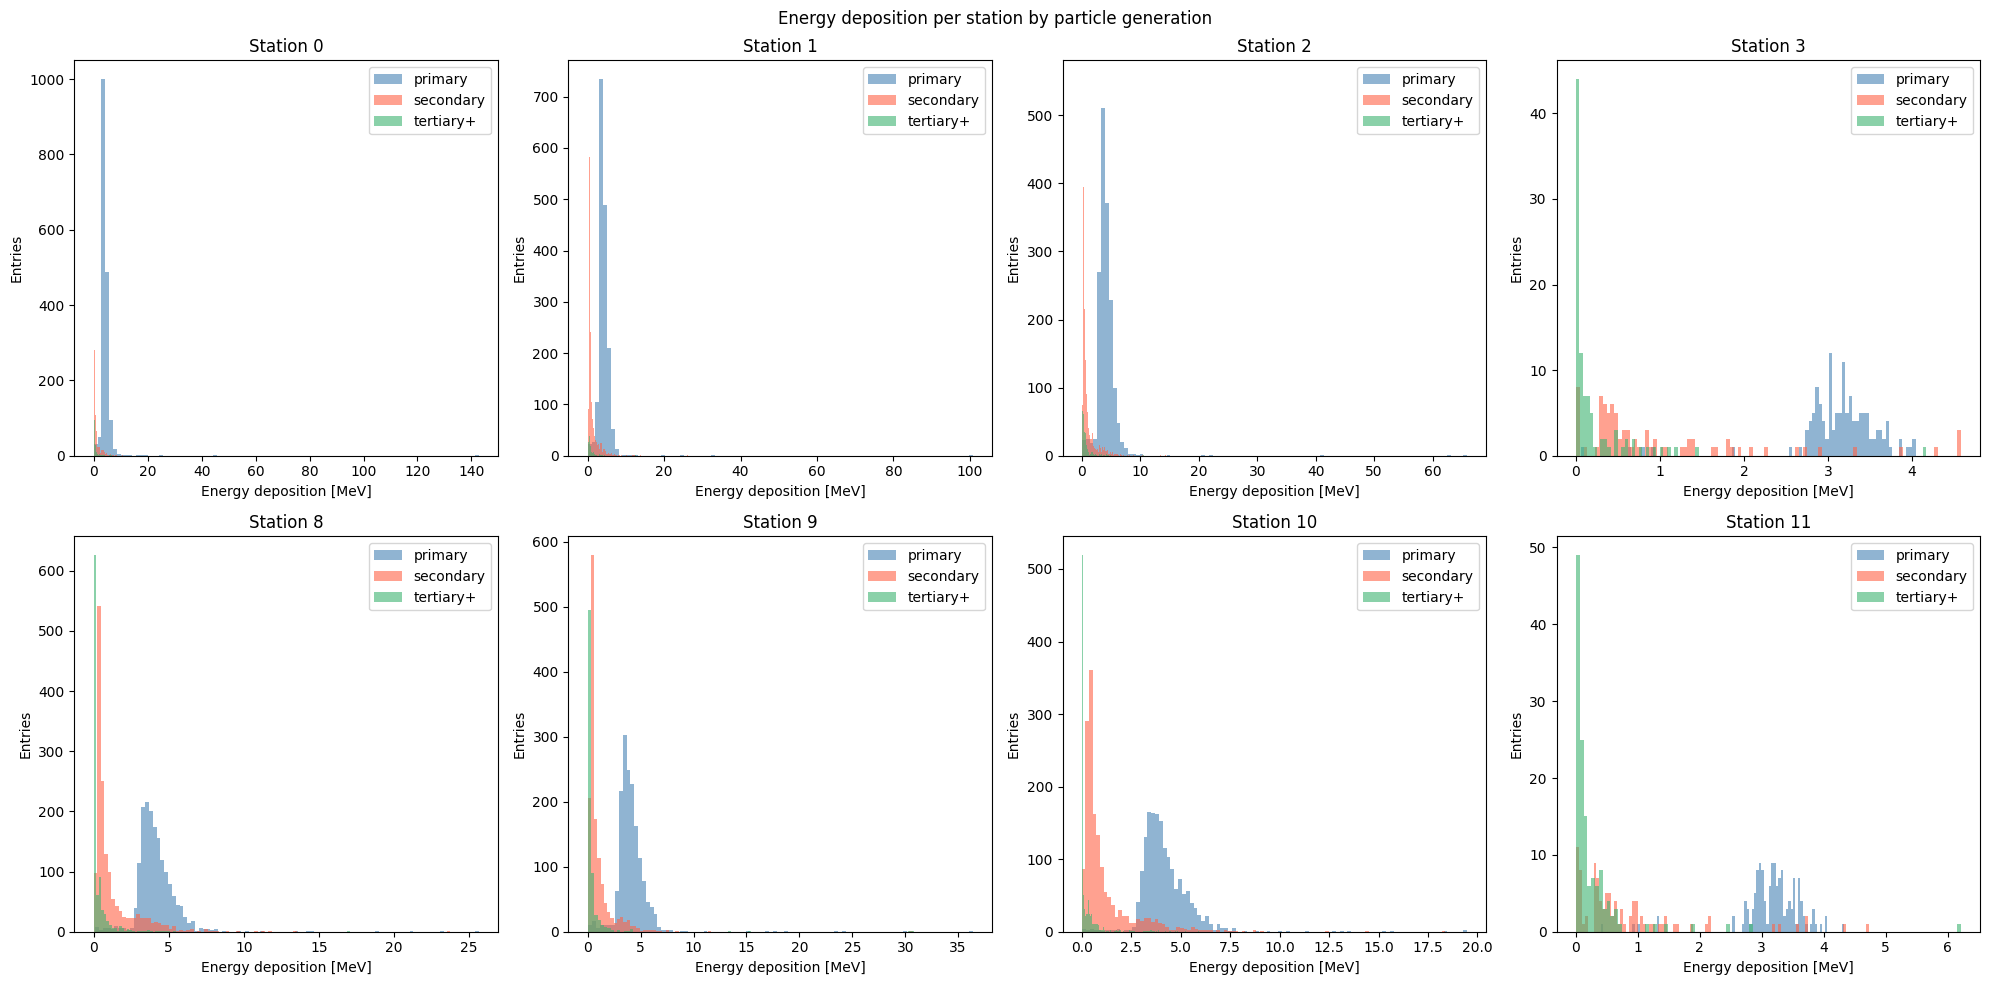

In [276]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (station, group) in zip(axes, hit_df.groupby("station")):
    for generation, color in zip(["primary", "secondary", "tertiary+"],
                                  ["steelblue", "tomato", "mediumseagreen"]):
        data = group[group["generation"] == generation]["energy"]
        if len(data) == 0:
            continue
        ax.hist(data, bins=100, alpha=0.6, label=generation,
                color=color, edgecolor="none")

    ax.set_title(f"Station {station}")
    ax.set_xlabel("Energy deposition [MeV]")
    ax.set_ylabel("Entries")
    #ax.set_yscale("log")
    ax.legend()

for ax in axes[len(hit_df["station"].unique()):]:
    ax.set_visible(False)

plt.suptitle("Energy deposition per station by particle generation")
plt.tight_layout()
plt.show()

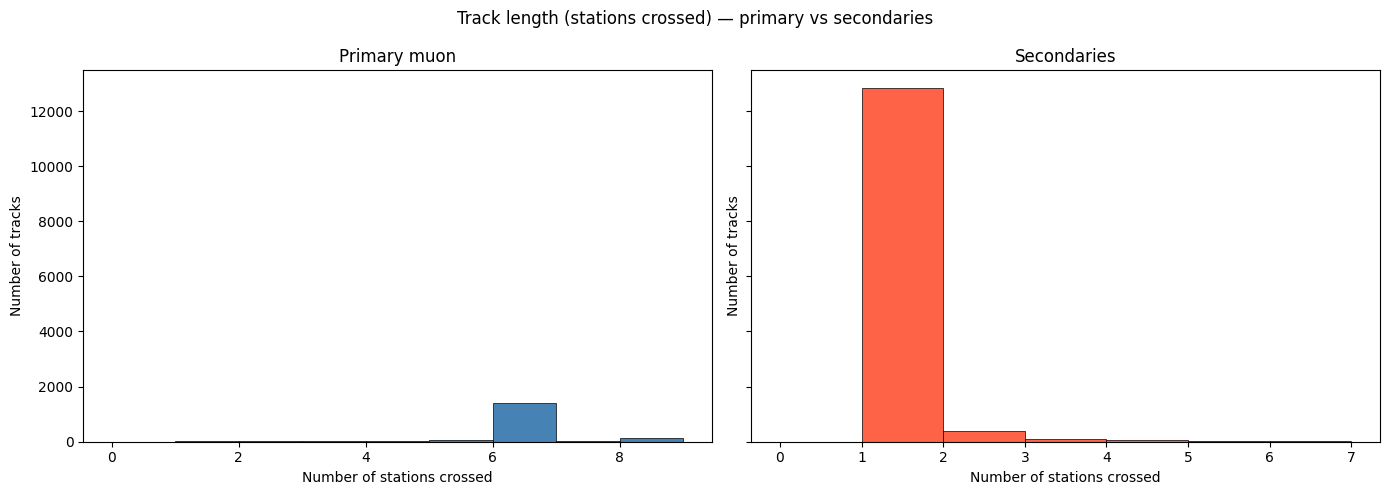

In [277]:
# ── 1. Track length: number of stations crossed per track ─────────────────

# Primary
primary_track_length = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby(["event", "track_id"])["station"]
    .nunique()
    .reset_index(name="n_stations")
)

# Secondary
secondary_track_length = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby(["event", "track_id"])["station"]
    .nunique()
    .reset_index(name="n_stations")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, title, color in zip(
    axes,
    [primary_track_length, secondary_track_length],
    ["Primary muon", "Secondaries"],
    ["steelblue", "tomato"]
):
    max_val = data["n_stations"].max()
    bins = np.arange(0, max_val + 2, 1)
    ax.hist(data["n_stations"], bins=bins, color=color, edgecolor="black", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Number of stations crossed")
    ax.set_ylabel("Number of tracks")

plt.suptitle("Track length (stations crossed) — primary vs secondaries")
plt.tight_layout()
plt.show()


primary:
  Fully adjacent tracks: 98.1%
  Max gap distribution:
  max_gap
0     9907
29       2
30       6
31     185
Name: count, dtype: int64


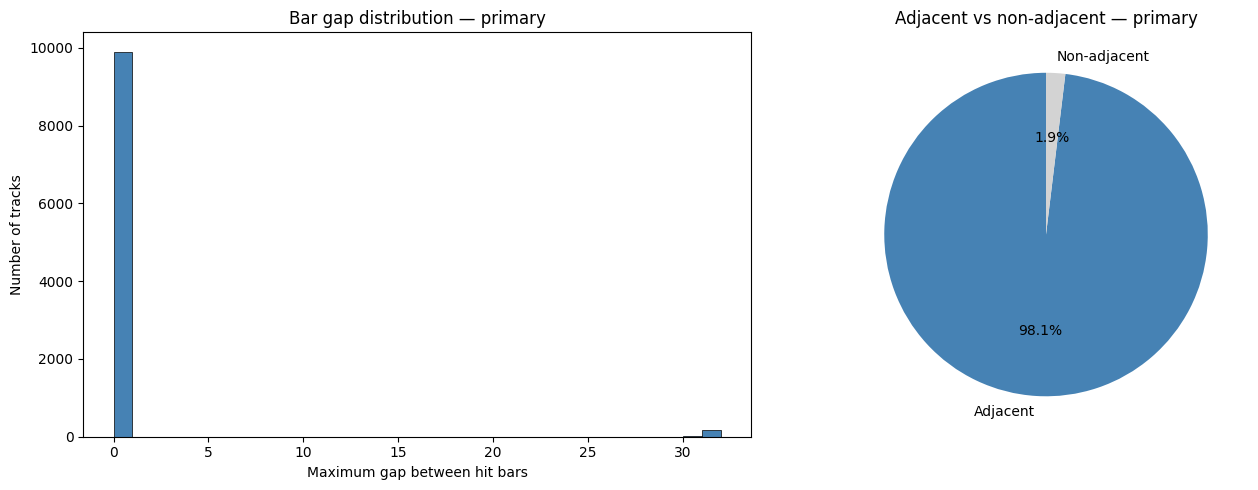


secondary:
  Fully adjacent tracks: 99.3%
  Max gap distribution:
  max_gap
0     14291
2         1
3         1
4         2
5         2
6         1
8         3
11        2
12        3
13        2
14        1
17        2
19        2
20        1
21        1
23        1
24        3
25        1
26        1
28        3
29        1
30        7
31       55
Name: count, dtype: int64


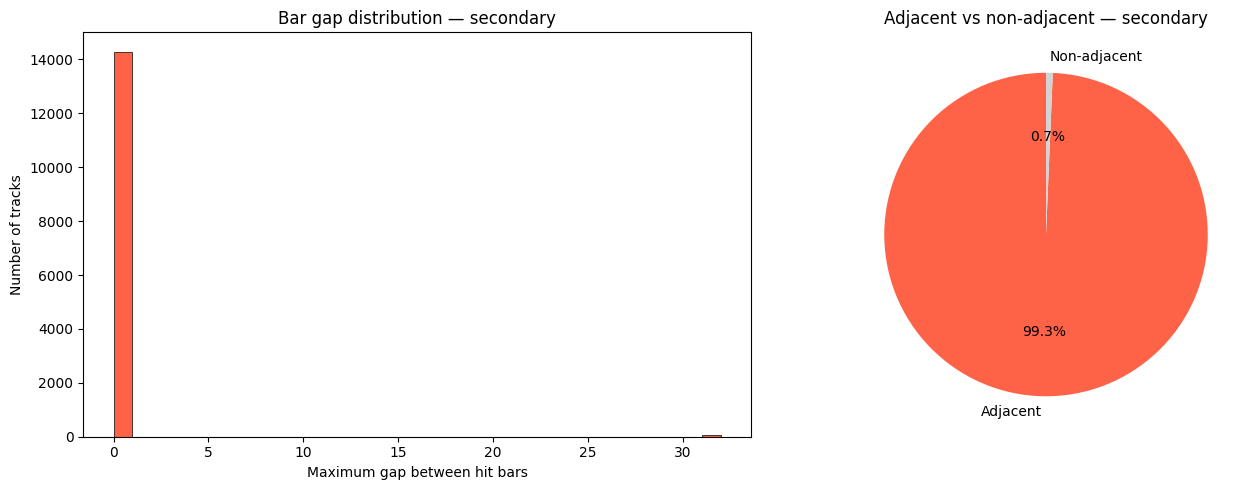

In [278]:
# ── 2. Bar adjacency: are bars hit by a track always neighboring? ─────────

def check_adjacency(bars):
    """Returns True if all hit bars are adjacent (no gaps)"""
    sorted_bars = np.sort(np.unique(bars))
    if len(sorted_bars) <= 1:
        return True
    gaps = np.diff(sorted_bars)
    return np.all(gaps == 1)

def max_gap(bars):
    """Returns the maximum gap between hit bars"""
    sorted_bars = np.sort(np.unique(bars))
    if len(sorted_bars) <= 1:
        return 0
    return np.diff(sorted_bars).max()

# Apply per track per event per station
for label, mask in zip(["primary", "secondary"], 
                        [hit_df["parent_id"] == 0, hit_df["parent_id"] > 0]):
    
    track_bars = (
        hit_df[mask]
        .groupby(["event", "track_id", "station"])["bar"]
        .apply(list)
        .reset_index(name="bars")
    )

    track_bars["adjacent"] = track_bars["bars"].apply(check_adjacency)
    track_bars["max_gap"]  = track_bars["bars"].apply(max_gap)

    pct_adjacent = track_bars["adjacent"].mean() * 100
    print(f"\n{label}:")
    print(f"  Fully adjacent tracks: {pct_adjacent:.1f}%")
    print(f"  Max gap distribution:")
    print(f"  {track_bars['max_gap'].value_counts().sort_index()}")

    # Plot max gap distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    max_val = track_bars["max_gap"].max()
    bins = np.arange(0, max_val + 2, 1)
    axes[0].hist(track_bars["max_gap"], bins=bins,
                 color="steelblue" if label == "primary" else "tomato",
                 edgecolor="black", linewidth=0.5)
    axes[0].set_xlabel("Maximum gap between hit bars")
    axes[0].set_ylabel("Number of tracks")
    axes[0].set_title(f"Bar gap distribution — {label}")

    # Fraction adjacent vs non-adjacent pie
    axes[1].pie([track_bars["adjacent"].sum(), (~track_bars["adjacent"]).sum()],
                labels=["Adjacent", "Non-adjacent"],
                autopct="%1.1f%%", startangle=90,
                colors=["steelblue" if label == "primary" else "tomato", "lightgray"])
    axes[1].set_title(f"Adjacent vs non-adjacent — {label}")

    plt.tight_layout()
    plt.show()

In [279]:
# ── 3. Station adjacency: is the track continuous across stations? ────────

def check_station_adjacency(stations):
    """Returns True if all hit stations are adjacent (no gaps)"""
    sorted_stations = np.sort(np.unique(stations))
    if len(sorted_stations) <= 1:
        return True
    gaps = np.diff(sorted_stations)
    return np.all(gaps == 1)

def max_station_gap(stations):
    """Returns the maximum gap between hit stations"""
    sorted_stations = np.sort(np.unique(stations))
    if len(sorted_stations) <= 1:
        return 0
    return np.diff(sorted_stations).max()

TRIGGERED_STATIONS = [0, 1, 2, 3, 4, 5]

for label, mask in zip(["primary", "secondary"],
                        [hit_df["parent_id"] == 0, hit_df["parent_id"] > 0]):

    track_stations = (
        hit_df[mask & hit_df["station"].isin(TRIGGERED_STATIONS)]
        .groupby(["event", "track_id"])["station"]
        .apply(list)
        .reset_index(name="stations")
    )

    track_stations["adjacent"] = track_stations["stations"].apply(check_station_adjacency)
    track_stations["max_gap"]  = track_stations["stations"].apply(max_station_gap)

    pct_adjacent = track_stations["adjacent"].mean() * 100
    print(f"\n{label} (stations 0-5 only):")
    print(f"  Fully adjacent tracks: {pct_adjacent:.1f}%")


primary (stations 0-5 only):
  Fully adjacent tracks: 98.0%

secondary (stations 0-5 only):
  Fully adjacent tracks: 98.9%


Adjacent events:     1652
Non-adjacent events: 34


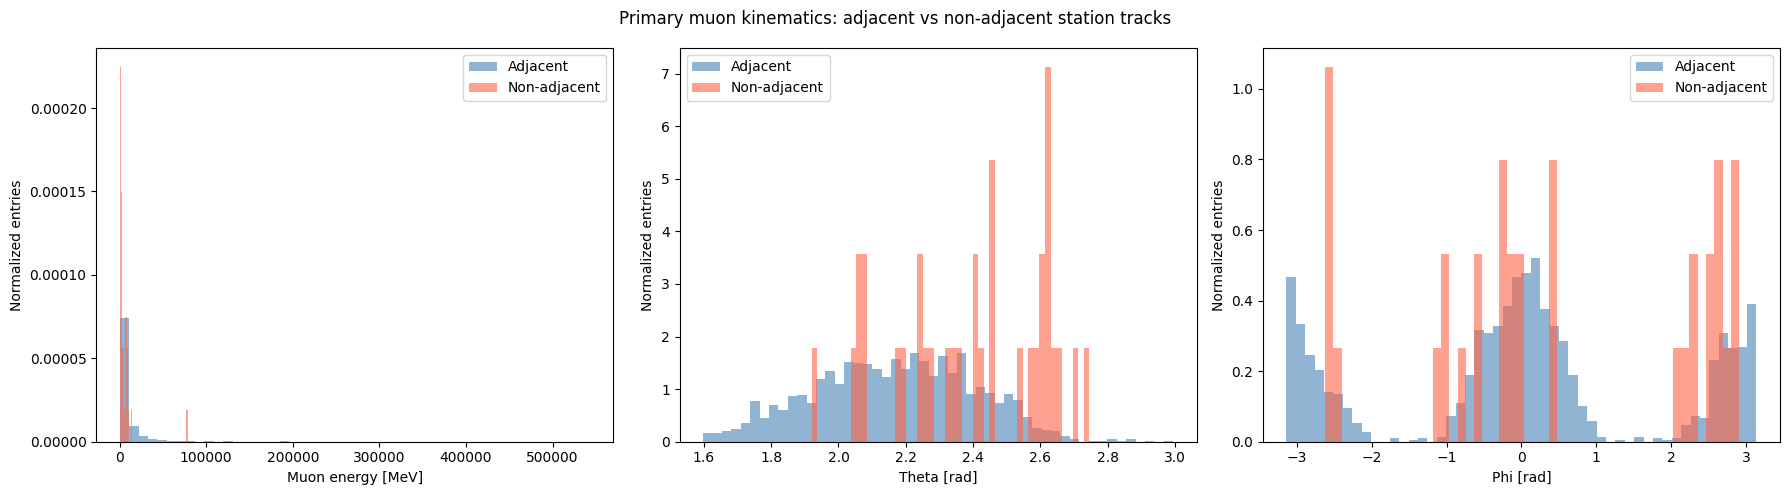

In [280]:
# Get non-adjacent primary events
track_stations_primary = (
    hit_df[(hit_df["parent_id"] == 0) & hit_df["station"].isin(TRIGGERED_STATIONS)]
    .groupby(["event", "track_id"])["station"]
    .apply(list)
    .reset_index(name="stations")
)
track_stations_primary["adjacent"] = track_stations_primary["stations"].apply(check_station_adjacency)

adjacent_events     = track_stations_primary[track_stations_primary["adjacent"]]["event"]
non_adjacent_events = track_stations_primary[~track_stations_primary["adjacent"]]["event"]

# Merge with gen info
gen_adjacent     = gen_df[gen_df["Event"].isin(adjacent_events)]
gen_non_adjacent = gen_df[gen_df["Event"].isin(non_adjacent_events)]

print(f"Adjacent events:     {len(adjacent_events)}")
print(f"Non-adjacent events: {len(non_adjacent_events)}")

# Plot energy, theta, phi comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, var, xlabel in zip(
    axes,
    ["GenPartE", "GenPartTheta", "GenPartPhi"],
    ["Muon energy [MeV]", "Theta [rad]", "Phi [rad]"]
):
    col.hist(gen_adjacent[var],     bins=50, alpha=0.6, label="Adjacent",     color="steelblue", density=True)
    col.hist(gen_non_adjacent[var], bins=50, alpha=0.6, label="Non-adjacent", color="tomato",    density=True)
    col.set_xlabel(xlabel)
    col.set_ylabel("Normalized entries")
    col.legend()

plt.suptitle("Primary muon kinematics: adjacent vs non-adjacent station tracks")
plt.tight_layout()
plt.show()

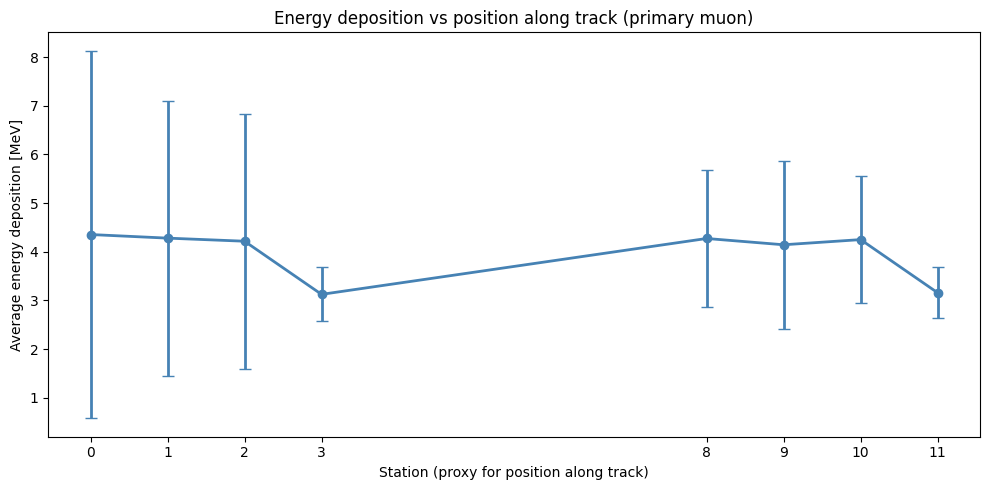

In [281]:
# ── 1. Energy deposition vs station (along the track) ────────────────────
# Use station as a proxy for position along the track

primary_edep_station = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby(["event", "station"])["energy"]
    .sum()
    .reset_index(name="edep")
)

# Average energy deposition per station across all events
avg_edep = primary_edep_station.groupby("station")["edep"].mean()
std_edep = primary_edep_station.groupby("station")["edep"].std()

plt.figure(figsize=(10, 5))
plt.errorbar(avg_edep.index, avg_edep.values, yerr=std_edep.values,
             fmt="o-", color="steelblue", capsize=4, linewidth=2)
plt.xlabel("Station (proxy for position along track)")
plt.ylabel("Average energy deposition [MeV]")
plt.title("Energy deposition vs position along track (primary muon)")
plt.xticks(avg_edep.index)
plt.tight_layout()
plt.show()

count    1728.000000
mean       31.749875
std        13.068452
min         0.215450
25%        25.244367
50%        29.649999
75%        35.699883
max       221.736385
Name: total_edep, dtype: float64


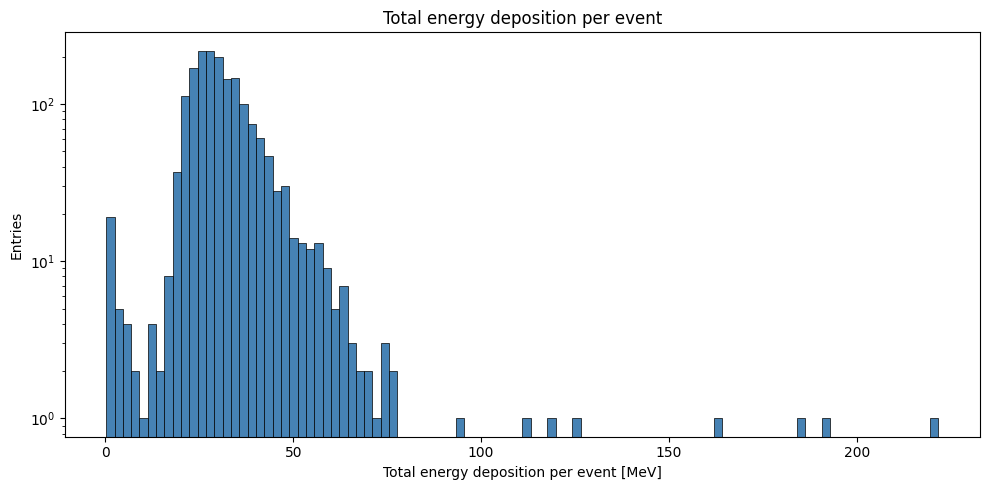

In [282]:
# ── 2. Total energy deposition per event ─────────────────────────────────

total_edep_per_event = (
    hit_df
    .groupby("event")["energy"]
    .sum()
    .reset_index(name="total_edep")
)

print(total_edep_per_event["total_edep"].describe())

plt.figure(figsize=(10, 5))
plt.hist(total_edep_per_event["total_edep"], bins=100, 
         color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Total energy deposition per event [MeV]")
plt.ylabel("Entries")
plt.title("Total energy deposition per event")
plt.yscale("log")
plt.tight_layout()
plt.show()

generation  frac_primary  frac_secondary  frac_tertiary+
count        1728.000000     1728.000000     1728.000000
mean            0.795007        0.169337        0.035656
std             0.179713        0.117645        0.134464
min             0.000000        0.000000        0.000000
25%             0.732313        0.083190        0.000000
50%             0.845108        0.145267        0.000101
75%             0.910750        0.230928        0.018996
max             1.000000        0.888713        1.000000


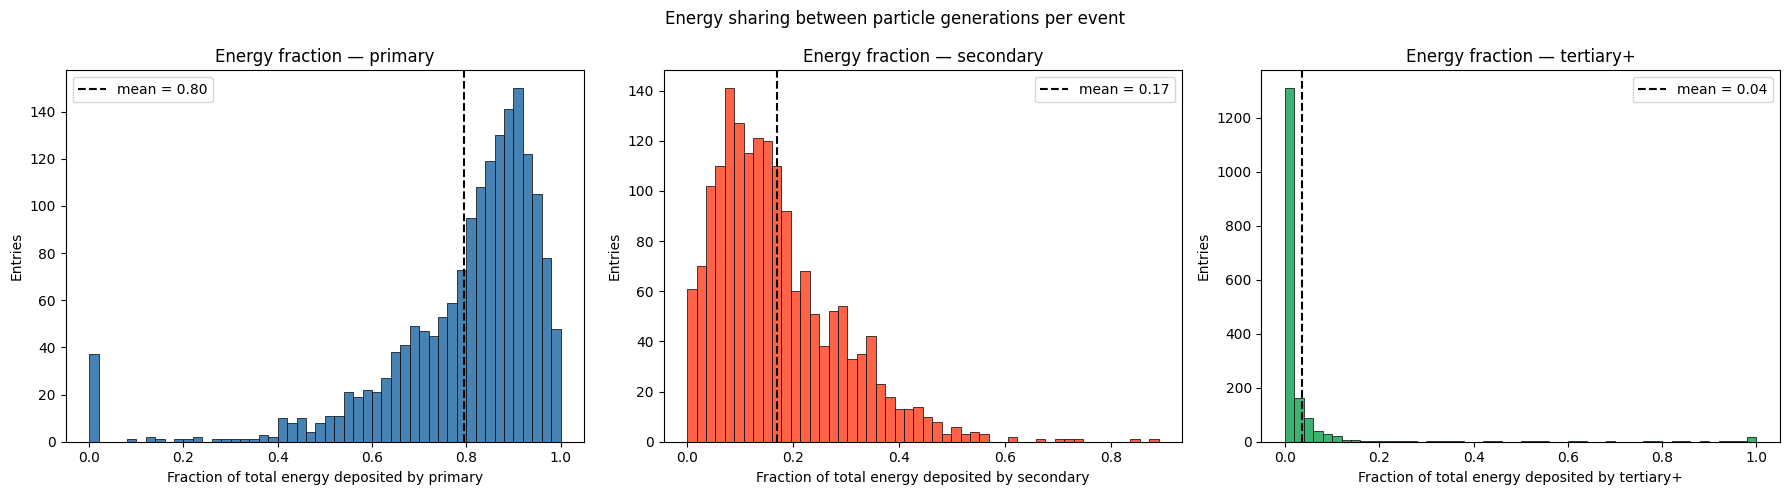

In [283]:
# ── 3. Energy sharing: primary vs secondaries per event ──────────────────

edep_by_generation = (
    hit_df
    .groupby(["event", "generation"])["energy"]
    .sum()
    .reset_index(name="edep")
)

# Pivot to get one column per generation
edep_pivot = edep_by_generation.pivot_table(
    index="event", columns="generation", values="edep", fill_value=0
)

# Compute total and fractions
edep_pivot["total"] = edep_pivot.sum(axis=1)
for gen in ["primary", "secondary", "tertiary+"]:
    if gen in edep_pivot.columns:
        edep_pivot[f"frac_{gen}"] = edep_pivot[gen] / edep_pivot["total"]

print(edep_pivot[[f"frac_{g}" for g in ["primary", "secondary", "tertiary+"] 
                  if f"frac_{g}" in edep_pivot.columns]].describe())

# Plot fraction distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (gen, color) in zip(axes, zip(
    ["primary", "secondary", "tertiary+"],
    ["steelblue", "tomato", "mediumseagreen"]
)):
    col = f"frac_{gen}"
    if col not in edep_pivot.columns:
        continue
    ax.hist(edep_pivot[col], bins=50, color=color, edgecolor="black", linewidth=0.5)
    ax.set_xlabel(f"Fraction of total energy deposited by {gen}")
    ax.set_ylabel("Entries")
    ax.set_title(f"Energy fraction — {gen}")
    ax.axvline(edep_pivot[col].mean(), color="black", linestyle="--", 
               label=f"mean = {edep_pivot[col].mean():.2f}")
    ax.legend()

plt.suptitle("Energy sharing between particle generations per event")
plt.tight_layout()
plt.show()

In [284]:
# Events where secondaries dominate
secondary_dominated = edep_pivot[edep_pivot["frac_secondary"] > 0.5]
print(f"Events where secondaries > 50% of energy: {len(secondary_dominated)}")

# Events where primary deposits nothing
no_primary = edep_pivot[edep_pivot["frac_primary"] == 0]
print(f"Events with no primary energy deposition: {len(no_primary)}")

# Events where tertiary dominates
tertiary_dominated = edep_pivot[edep_pivot["frac_tertiary+"] > 0.5]
print(f"Events where tertiary > 50% of energy: {len(tertiary_dominated)}")

# Look at their muon kinematics
for label, events in zip(
    ["secondary dominated", "no primary", "tertiary dominated"],
    [secondary_dominated, no_primary, tertiary_dominated]
):
    gen_subset = gen_df[gen_df["Event"].isin(events.index)]
    print(f"\n{label} — muon kinematics:")
    print(gen_subset[["GenPartE", "GenPartTheta", "GenPartPhi"]].describe())

Events where secondaries > 50% of energy: 24
Events with no primary energy deposition: 37
Events where tertiary > 50% of energy: 38

secondary dominated — muon kinematics:
           GenPartE  GenPartTheta  GenPartPhi
count     24.000000     24.000000   24.000000
mean    6179.945552      2.227069   -0.194525
std     6162.836659      0.355229    2.077037
min      157.566210      1.709726   -2.959490
25%     1525.930377      1.924447   -2.189923
50%     3633.566377      2.191195   -0.269704
75%    10593.998363      2.435825    1.974264
max    20205.343985      2.961529    3.096328

no primary — muon kinematics:
            GenPartE  GenPartTheta  GenPartPhi
count      37.000000     37.000000   37.000000
mean    19456.347259      2.573007    0.236788
std     78386.200111      0.311068    1.664311
min       141.468732      1.826872   -2.909536
25%       873.970941      2.456612   -1.199436
50%      1399.070347      2.660647    0.229362
75%      5298.225785      2.801789    1.428945
max    

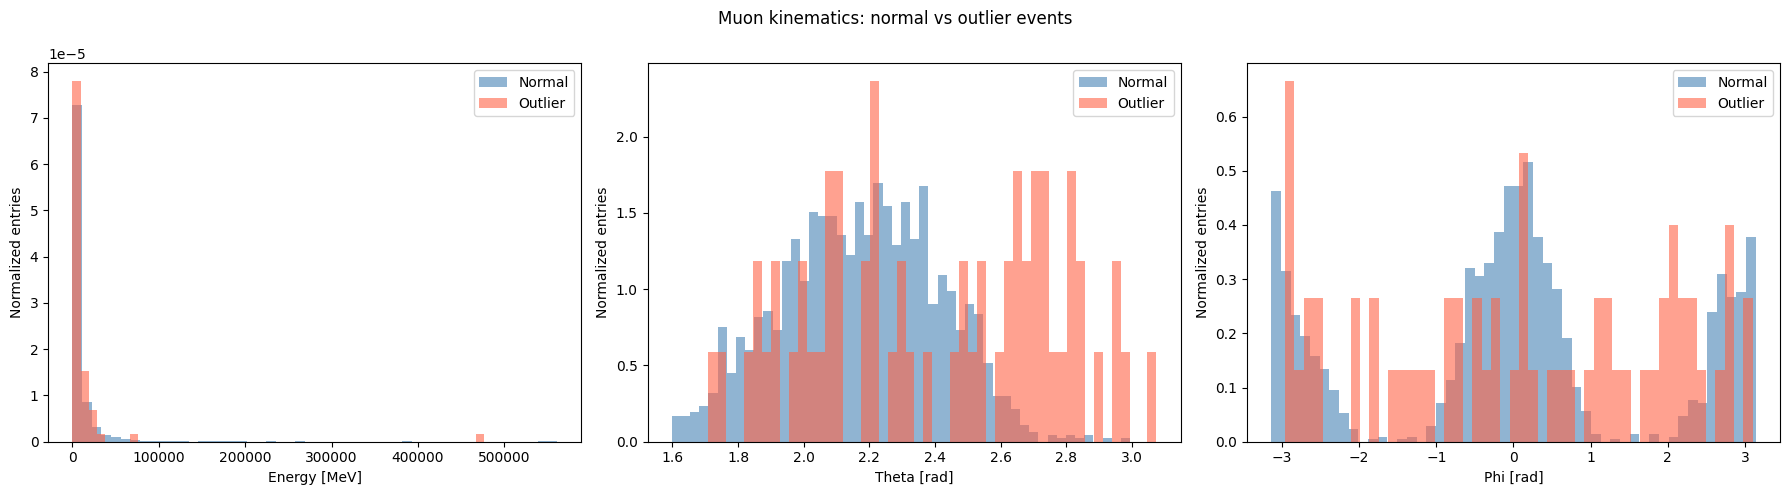

In [285]:
# Visualize theta distribution: normal vs outlier events
outlier_events = set(no_primary.index) | set(secondary_dominated.index) | set(tertiary_dominated.index)
normal_events  = set(gen_df["Event"]) - outlier_events

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var, xlabel in zip(
    axes,
    ["GenPartE", "GenPartTheta", "GenPartPhi"],
    ["Energy [MeV]", "Theta [rad]", "Phi [rad]"]
):
    ax.hist(gen_df[gen_df["Event"].isin(normal_events)][var],
            bins=50, alpha=0.6, density=True, color="steelblue", label="Normal")
    ax.hist(gen_df[gen_df["Event"].isin(outlier_events)][var],
            bins=50, alpha=0.6, density=True, color="tomato",    label="Outlier")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized entries")
    ax.legend()

plt.suptitle("Muon kinematics: normal vs outlier events")
plt.tight_layout()
plt.show()

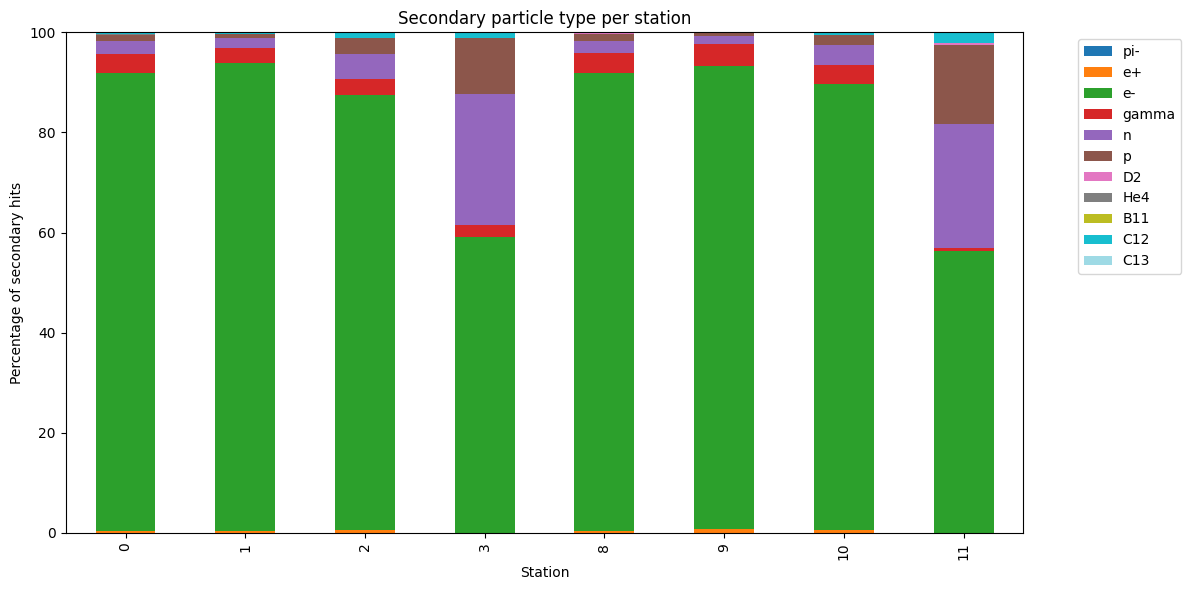

In [286]:
# ── 1. Secondary PDG vs station ───────────────────────────────────

from particle import Particle

def pdg_to_name(pdg):
    try:
        return Particle.from_pdgid(pdg).name
    except:
        return f"PDG {pdg}"

secondary_origin = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby(["station", "pdg"])
    .size()
    .reset_index(name="count")
)

# Pivot: rows=station, columns=pdg
pivot = secondary_origin.pivot_table(
    index="station", columns="pdg", values="count", fill_value=0
)
pivot.columns = [pdg_to_name(p) for p in pivot.columns]

# Normalize to percentage per station
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Plot stacked bar
pivot_pct.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")
plt.xlabel("Station")
plt.ylabel("Percentage of secondary hits")
plt.title("Secondary particle type per station")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

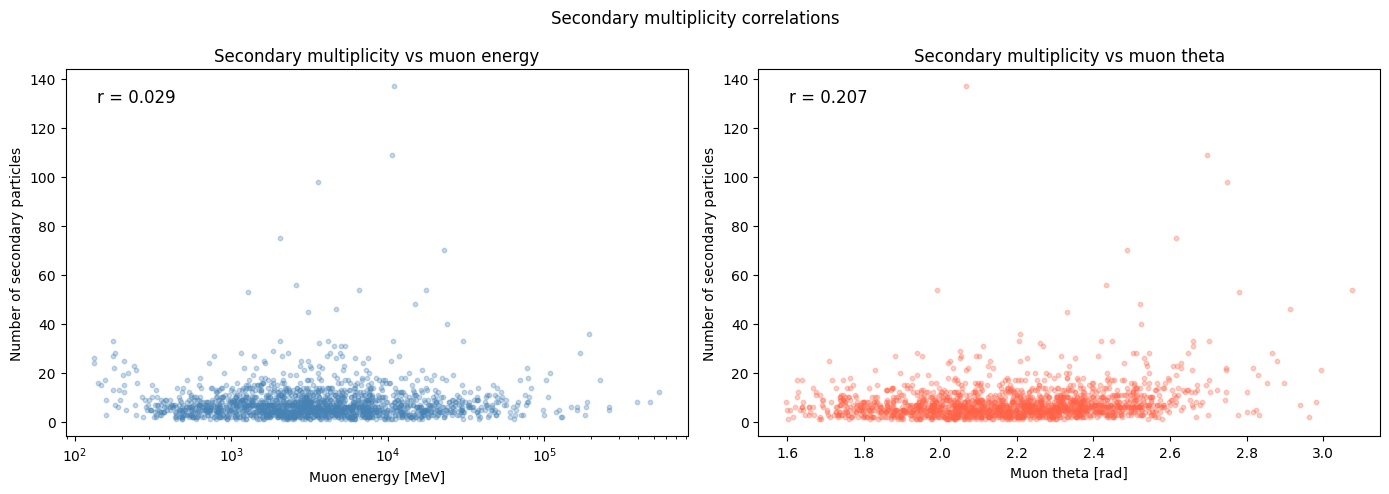

In [287]:
n_secondaries = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby("event")["track_id"]
    .nunique()
    .reset_index(name="n_secondaries")
)

# Merge with gen info using correct column names
merged = n_secondaries.merge(gen_df[["Event", "GenPartE", "GenPartTheta"]], 
                              left_on="event", right_on="Event")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(merged["GenPartE"], merged["n_secondaries"], 
                alpha=0.3, color="steelblue", s=10)
axes[0].set_xlabel("Muon energy [MeV]")
axes[0].set_ylabel("Number of secondary particles")
axes[0].set_title("Secondary multiplicity vs muon energy")
axes[0].set_xscale("log")

axes[1].scatter(merged["GenPartTheta"], merged["n_secondaries"],
                alpha=0.3, color="tomato", s=10)
axes[1].set_xlabel("Muon theta [rad]")
axes[1].set_ylabel("Number of secondary particles")
axes[1].set_title("Secondary multiplicity vs muon theta")

for ax, var in zip(axes, ["GenPartE", "GenPartTheta"]):
    corr = merged[var].corr(merged["n_secondaries"])
    ax.annotate(f"r = {corr:.3f}", xy=(0.05, 0.95),
                xycoords="axes fraction", fontsize=12,
                verticalalignment="top")

plt.suptitle("Secondary multiplicity correlations")
plt.tight_layout()
plt.show()

Correlation path length vs n_secondaries: r = -0.387


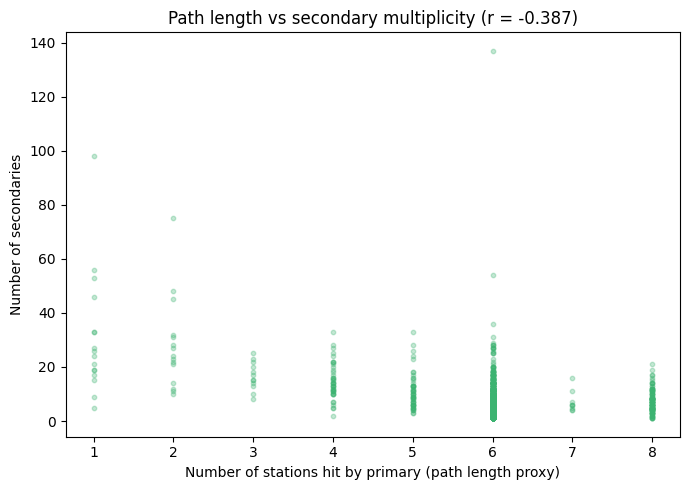

In [288]:
# Path length proxy: number of stations hit by primary
path_length = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby("event")["station"]
    .nunique()
    .reset_index(name="n_stations")
)

merged2 = merged.merge(path_length, on="event")
corr = merged2["n_stations"].corr(merged2["n_secondaries"])
print(f"Correlation path length vs n_secondaries: r = {corr:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(merged2["n_stations"], merged2["n_secondaries"],
            alpha=0.3, color="mediumseagreen", s=10)
plt.xlabel("Number of stations hit by primary (path length proxy)")
plt.ylabel("Number of secondaries")
plt.title(f"Path length vs secondary multiplicity (r = {corr:.3f})")
plt.tight_layout()
plt.show()

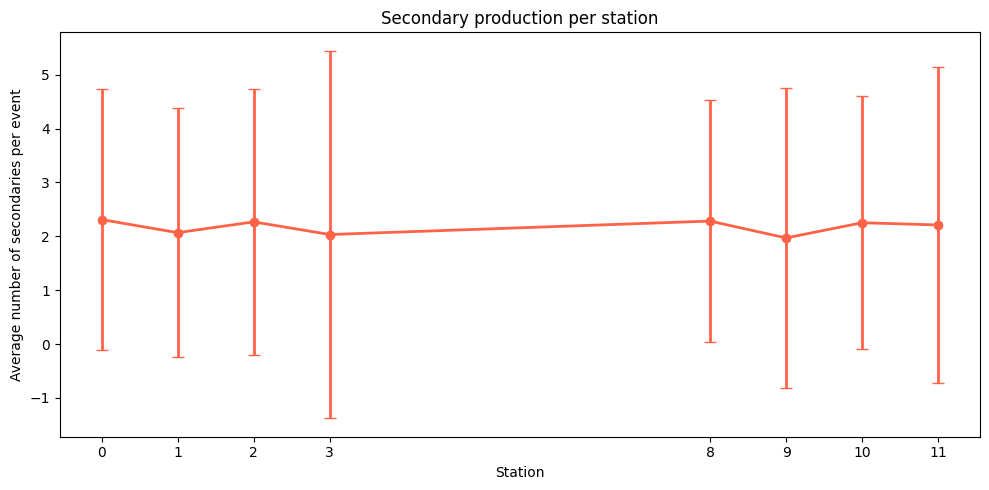

In [289]:
# ── 3. Which stations produce the most secondaries? ──────────────────────

# Count unique secondary tracks per station per event, then average
secondaries_per_station = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby(["event", "station"])["track_id"]
    .nunique()
    .reset_index(name="n_secondaries")
)

avg_secondaries = secondaries_per_station.groupby("station")["n_secondaries"].mean()
std_secondaries = secondaries_per_station.groupby("station")["n_secondaries"].std()

plt.figure(figsize=(10, 5))
plt.errorbar(avg_secondaries.index, avg_secondaries.values, yerr=std_secondaries.values,
             fmt="o-", color="tomato", capsize=4, linewidth=2)
plt.xlabel("Station")
plt.ylabel("Average number of secondaries per event")
plt.title("Secondary production per station")
plt.xticks(avg_secondaries.index)
plt.tight_layout()
plt.show()

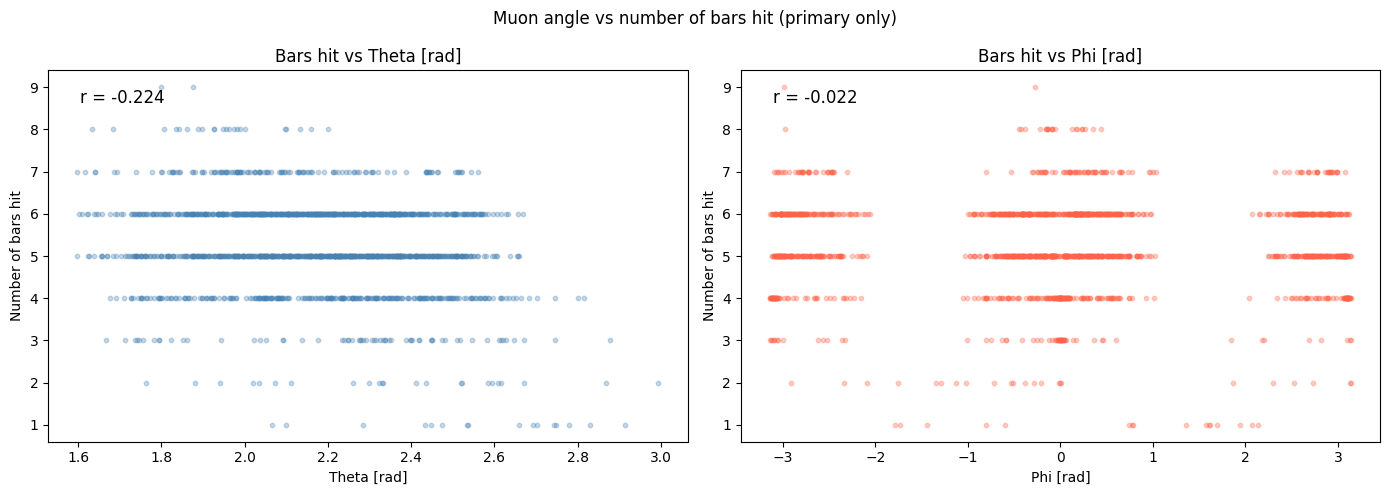

In [290]:
# ── 1. Muon angle vs number of bars hit ──────────────────────────────────

bars_hit = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby("event")["bar"]
    .nunique()
    .reset_index(name="n_bars")
)

merged = bars_hit.merge(gen_df[["Event", "GenPartTheta", "GenPartPhi"]],
                         left_on="event", right_on="Event")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, xlabel, color in zip(
    axes,
    ["GenPartTheta", "GenPartPhi"],
    ["Theta [rad]", "Phi [rad]"],
    ["steelblue", "tomato"]
):
    ax.scatter(merged[var], merged["n_bars"], alpha=0.3, color=color, s=10)
    corr = merged[var].corr(merged["n_bars"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of bars hit")
    ax.set_title(f"Bars hit vs {xlabel}")
    ax.annotate(f"r = {corr:.3f}", xy=(0.05, 0.95),
                xycoords="axes fraction", fontsize=12,
                verticalalignment="top")

plt.suptitle("Muon angle vs number of bars hit (primary only)")
plt.tight_layout()
plt.show()

In [291]:
# ── 2. Muon angle vs energy deposition ───────────────────────────────────

edep_primary = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby("event")["energy"]
    .sum()
    .reset_index(name="edep")
)

merged_edep = edep_primary.merge(gen_df[["GenPartEvent", "GenPartTheta", "GenPartPhi"]],
                                  left_on="event", right_on="GenPartEvent")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (var, xlabel, color) in zip(axes, [
    ("GenPartTheta", "Theta [rad]", "steelblue"),
    ("GenPartPhi",   "Phi [rad]",   "tomato")
]):
    ax.scatter(merged_edep[var], merged_edep["edep"], alpha=0.3, s=10, color=color)
    corr = merged_edep[var].corr(merged_edep["edep"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Energy deposition [MeV]")
    ax.set_title(f"Edep vs {xlabel}")
    ax.annotate(f"r = {corr:.3f}", xy=(0.05, 0.95),
                xycoords="axes fraction", fontsize=12,
                verticalalignment="top")

plt.suptitle("Muon angle vs energy deposition (primary only)")
plt.tight_layout()
plt.show()

KeyError: "['GenPartEvent'] not in index"

In [ ]:
# Build a dataframe with all variables of interest
analysis_df = merged_edep.merge(bars_hit, on="event").merge(n_secondaries, on="event")

vars_of_interest = ["GenPartTheta", "GenPartPhi", "edep", "n_bars", "n_secondaries"]

for method in ["pearson", "spearman", "kendall"]:
    print(f"\n── {method.capitalize()} correlation ──")
    print(analysis_df[vars_of_interest].corr(method=method).round(3))


── Pearson correlation ──
               GenPartTheta  GenPartPhi   edep  n_bars  n_secondaries
GenPartTheta          1.000       0.029  0.487  -0.225          0.188
GenPartPhi            0.029       1.000  0.034  -0.021          0.006
edep                  0.487       0.034  1.000  -0.028          0.225
n_bars               -0.225      -0.021 -0.028   1.000         -0.272
n_secondaries         0.188       0.006  0.225  -0.272          1.000

── Spearman correlation ──
               GenPartTheta  GenPartPhi   edep  n_bars  n_secondaries
GenPartTheta          1.000       0.013  0.557  -0.176          0.183
GenPartPhi            0.013       1.000  0.029   0.002         -0.025
edep                  0.557       0.029  1.000   0.095          0.213
n_bars               -0.176       0.002  0.095   1.000         -0.116
n_secondaries         0.183      -0.025  0.213  -0.116          1.000

── Kendall correlation ──
               GenPartTheta  GenPartPhi   edep  n_bars  n_secondaries
GenPartT

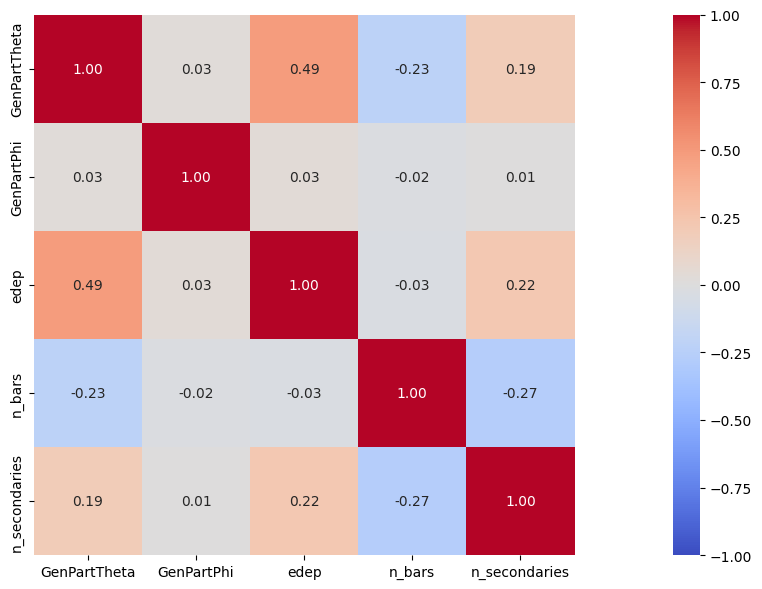

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 1, figsize=(20, 6))

for method in ["pearson"]:
    corr = analysis_df[vars_of_interest].corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", 
                vmin=-1, vmax=1, ax=axes, square=True)
    ax.set_title(f"{method.capitalize()} correlation")

plt.tight_layout()
plt.show()

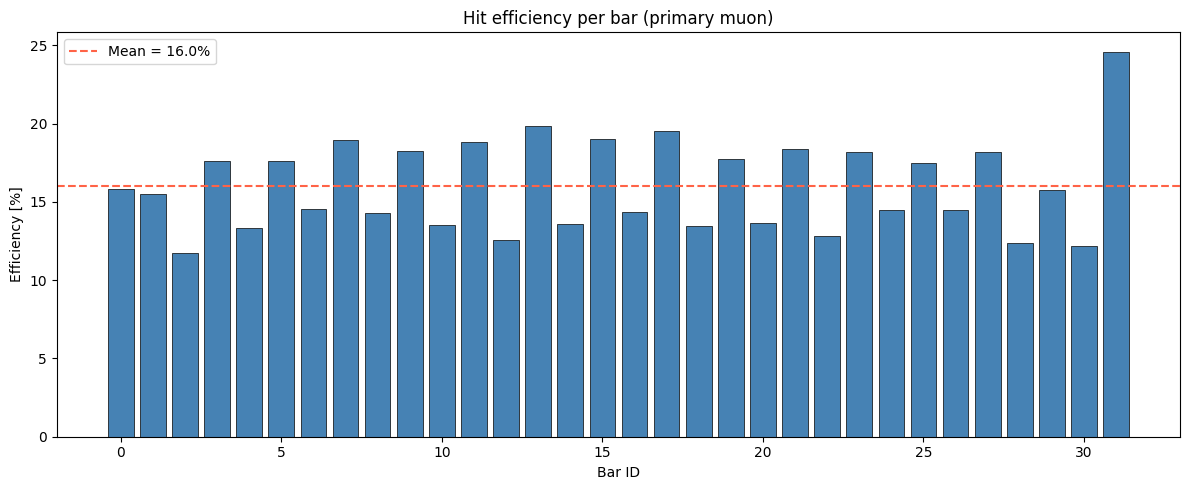

Most active bar:  31 (24.6%)
Least active bar: 2 (11.7%)


In [ ]:
# ── 1. Hit efficiency per bar ─────────────────────────────────────────────

total_events = hit_df["event"].nunique()

# Count how many events each bar was hit in
bar_efficiency = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby("bar")["event"]
    .nunique()
    / total_events * 100
)

plt.figure(figsize=(12, 5))
plt.bar(bar_efficiency.index, bar_efficiency.values,
        color="steelblue", edgecolor="black", linewidth=0.5)
plt.xlabel("Bar ID")
plt.ylabel("Efficiency [%]")
plt.title("Hit efficiency per bar (primary muon)")
plt.axhline(bar_efficiency.mean(), color="tomato", linestyle="--",
            label=f"Mean = {bar_efficiency.mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Most active bar:  {bar_efficiency.idxmax()} ({bar_efficiency.max():.1f}%)")
print(f"Least active bar: {bar_efficiency.idxmin()} ({bar_efficiency.min():.1f}%)")

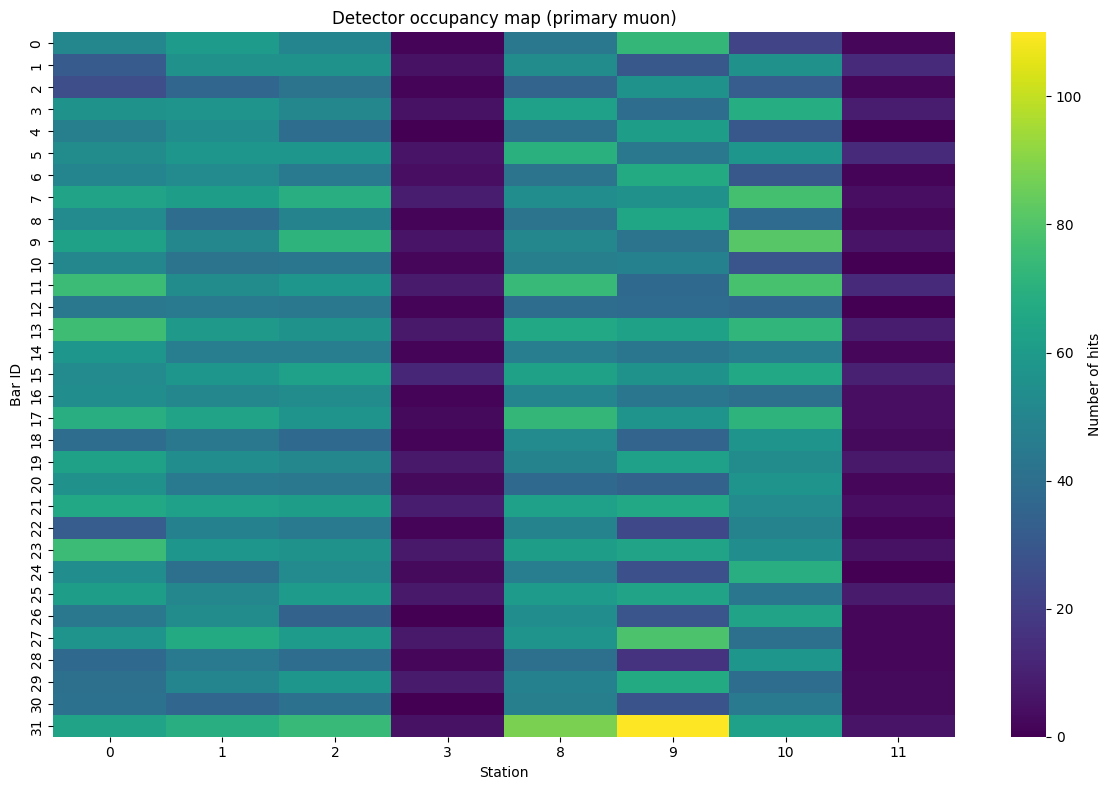

In [ ]:
# ── 2. Detector occupancy map ─────────────────────────────────────────────

occupancy = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby(["station", "bar"])
    .size()
    .reset_index(name="nhits")
)

pivot = occupancy.pivot_table(index="bar", columns="station", values="nhits", fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap="viridis", annot=False, 
            cbar_kws={"label": "Number of hits"})
plt.xlabel("Station")
plt.ylabel("Bar ID")
plt.title("Detector occupancy map (primary muon)")
plt.tight_layout()
plt.show()

In [ ]:
# ── 3. Landau distribution fit ────────────────────────────────────────────
# pip install pylandau

import pylandau
from scipy.optimize import curve_fit

# Use primary muon hit energies
edep = hit_df[hit_df["parent_id"] == 0]["energy"].values

# Histogram
counts, bin_edges = np.histogram(edep, bins=200)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit Landau
def landau(x, mpv, eta, A):
    return A * pylandau.landau(x, mpv, eta)

# Initial parameter guesses
p0 = [np.median(edep), np.std(edep) * 0.2, counts.max()]

try:
    popt, pcov = curve_fit(landau, bin_centers, counts, p0=p0, maxfev=10000)
    mpv, eta, A = popt
    print(f"MPV (Most Probable Value): {mpv:.4f} MeV")
    print(f"Eta (width parameter):     {eta:.4f} MeV")

    x_fit = np.linspace(bin_centers[0], bin_centers[-1], 1000)
    y_fit = landau(x_fit, *popt)

    plt.figure(figsize=(10, 5))
    plt.stairs(counts, bin_edges, color="steelblue", label="Data")
    plt.plot(x_fit, y_fit, color="tomato", linewidth=2,
             label=f"Landau fit\nMPV = {mpv:.4f} MeV\nη = {eta:.4f} MeV")
    plt.xlabel("Energy deposition [MeV]")
    plt.ylabel("Entries")
    plt.yscale("log")
    plt.title("Landau fit — primary muon energy deposition")
    plt.legend()
    plt.tight_layout()
    plt.show()

except RuntimeError:
    print("Fit did not converge, try adjusting p0 or bin range")

_IncompleteInputError: incomplete input (2009241284.py, line 32)

MPV (Most Probable Value): 3.5837 ± 0.0037 MeV
Sigma (width):             0.4957 ± 0.0030 MeV


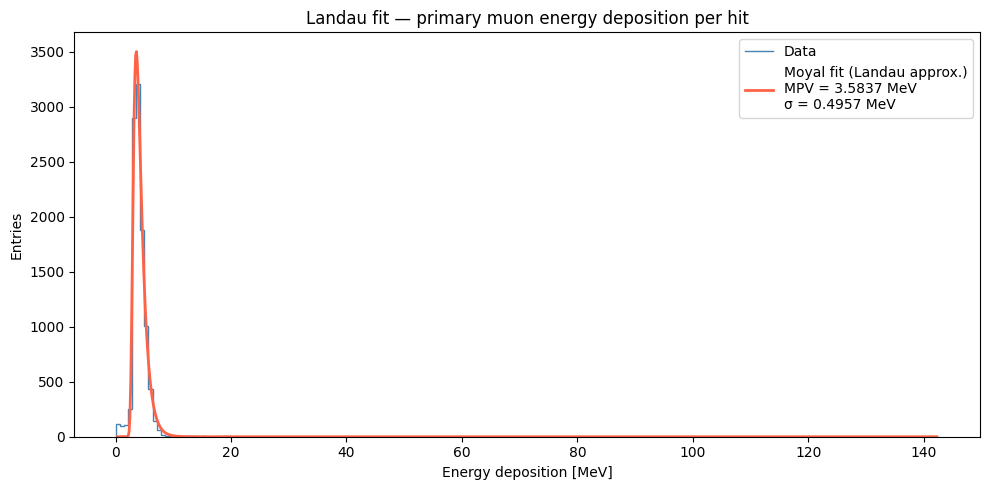

In [ ]:
from scipy.stats import moyal
from scipy.optimize import curve_fit

# Moyal distribution is a good approximation of the Landau
edep = hit_df[hit_df["parent_id"] == 0]["energy"].values

# Histogram
counts, bin_edges = np.histogram(edep, bins=200)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit Moyal (Landau approximation) using scipy
def moyal_fit(x, mpv, sigma, A):
    return A * moyal.pdf(x, loc=mpv, scale=sigma)

p0 = [np.median(edep), np.std(edep) * 0.2, counts.max()]

try:
    popt, pcov = curve_fit(moyal_fit, bin_centers, counts, p0=p0, maxfev=10000)
    mpv, sigma, A = popt
    perr = np.sqrt(np.diag(pcov))

    print(f"MPV (Most Probable Value): {mpv:.4f} ± {perr[0]:.4f} MeV")
    print(f"Sigma (width):             {sigma:.4f} ± {perr[1]:.4f} MeV")

    x_fit = np.linspace(bin_centers[0], bin_centers[-1], 1000)
    y_fit = moyal_fit(x_fit, *popt)

    plt.figure(figsize=(10, 5))
    plt.stairs(counts, bin_edges, color="steelblue", label="Data")
    plt.plot(x_fit, y_fit, color="tomato", linewidth=2,
             label=f"Moyal fit (Landau approx.)\nMPV = {mpv:.4f} MeV\nσ = {sigma:.4f} MeV")
    plt.xlabel("Energy deposition [MeV]")
    plt.ylabel("Entries")
    #plt.yscale("log")
    plt.title("Landau fit — primary muon energy deposition per hit")
    plt.legend()
    plt.tight_layout()
    plt.show()

except RuntimeError:
    print("Fit did not converge, try adjusting p0 or restricting energy range")

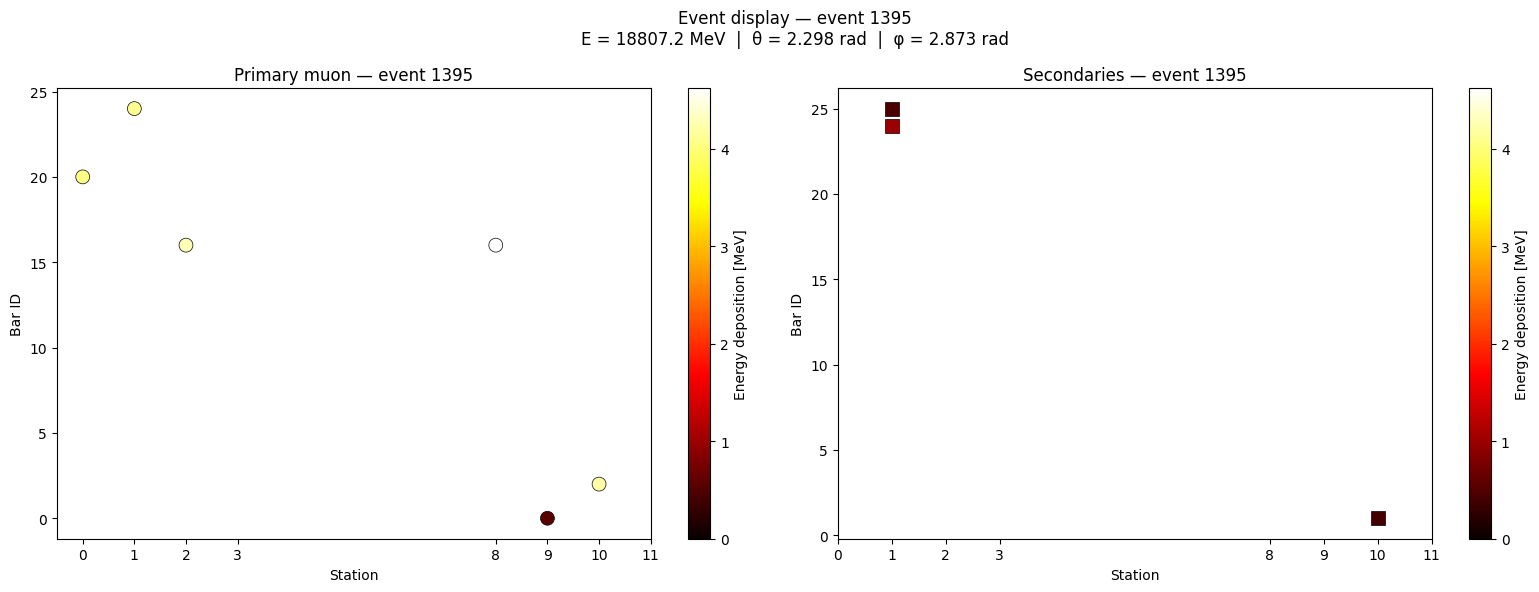

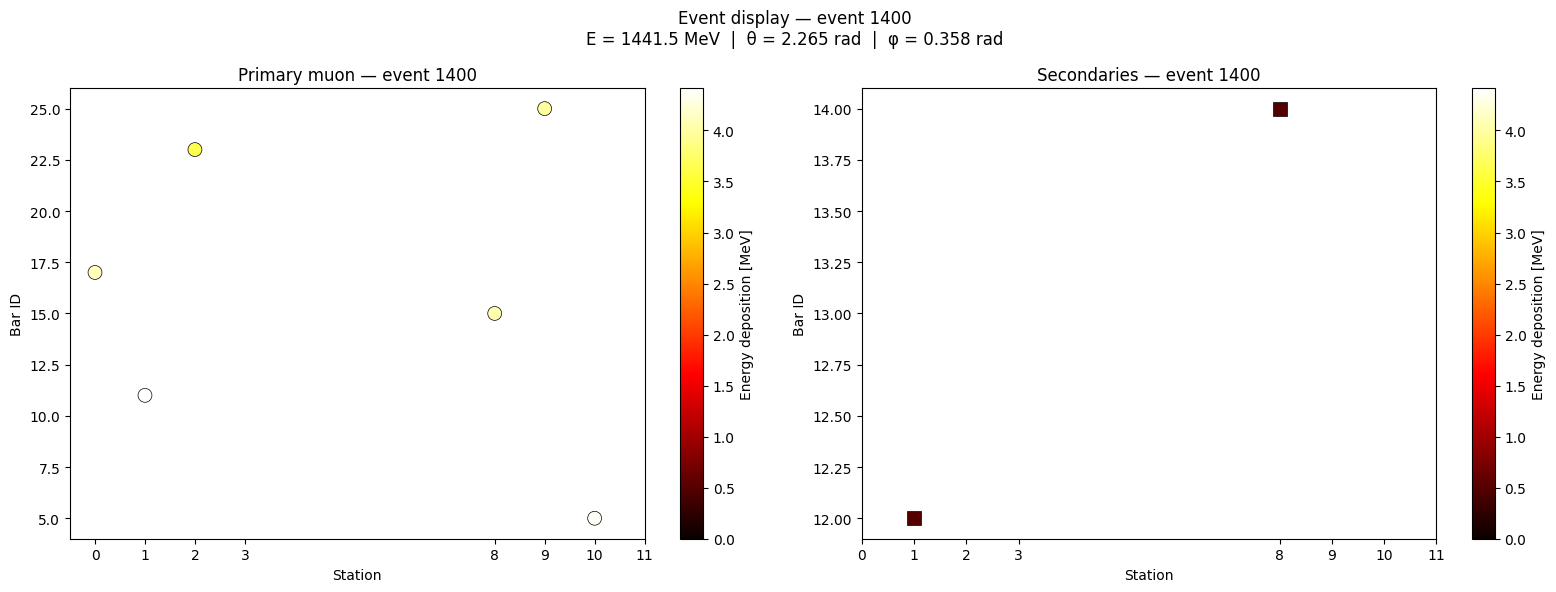

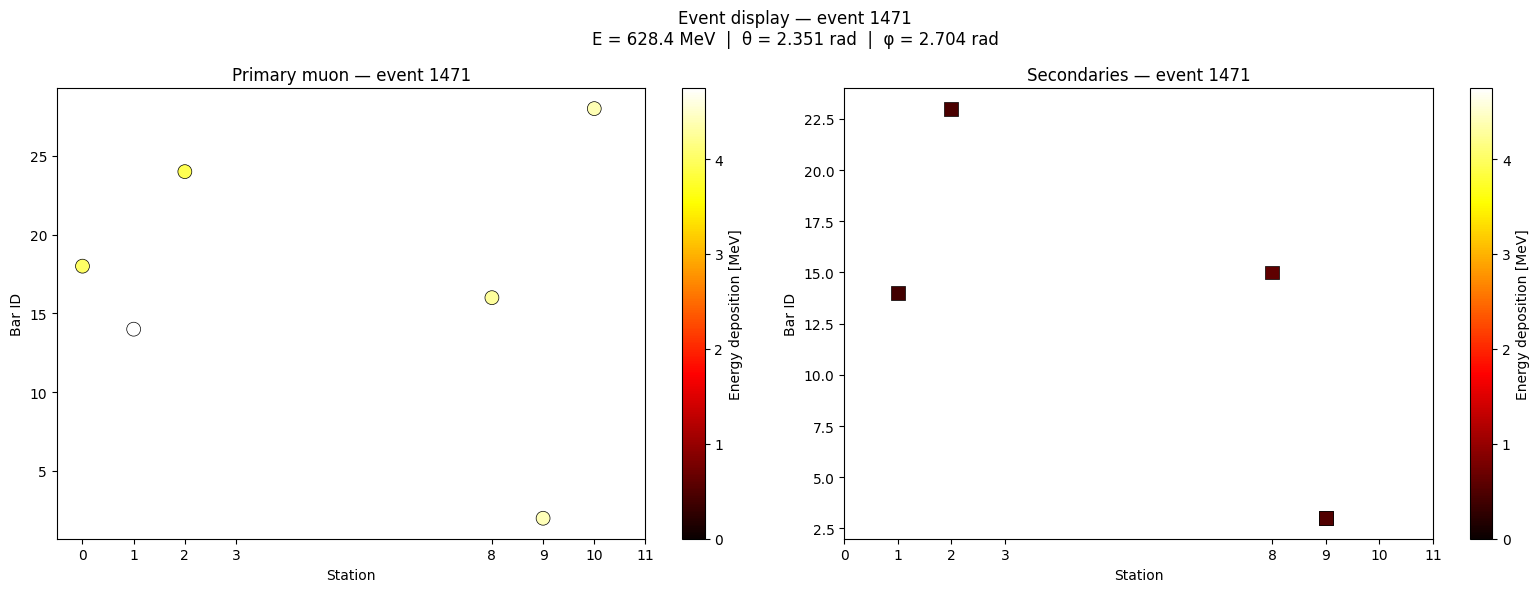

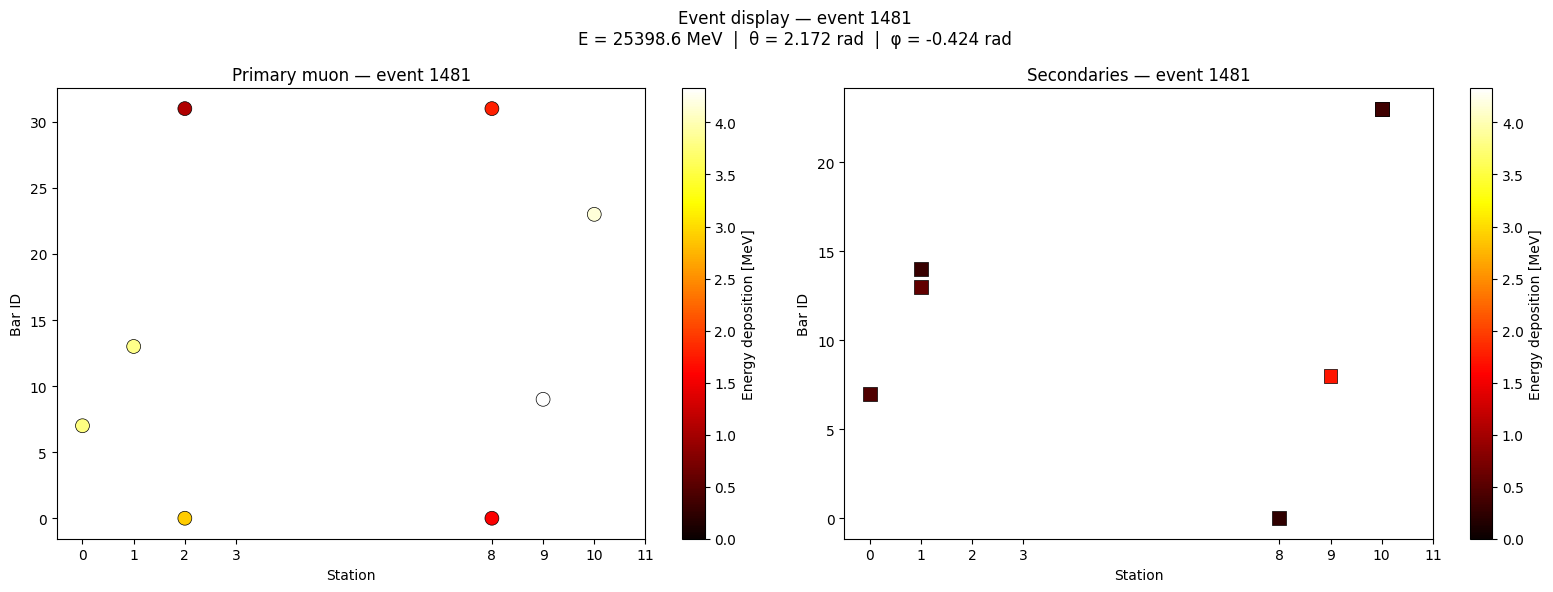

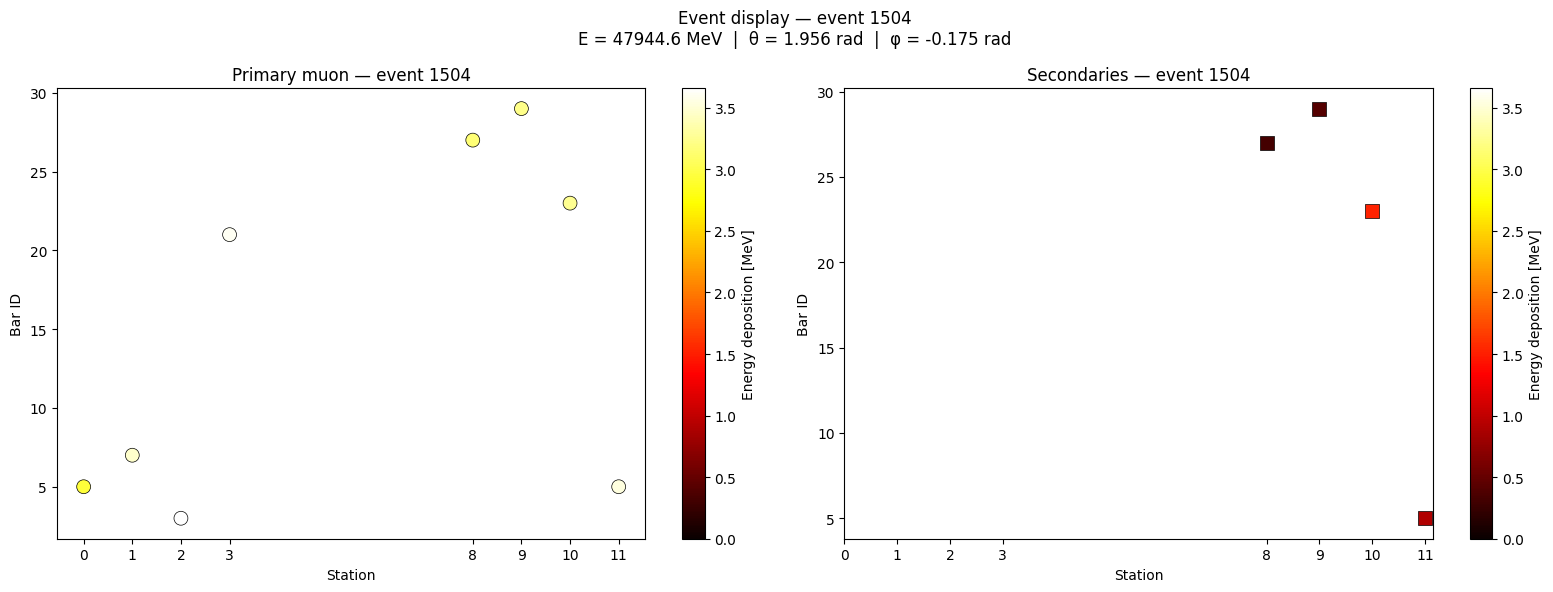

In [ ]:
# ── 5. Event display ──────────────────────────────────────────────────────

def plot_event_display(event_id):
    event = hit_df[hit_df["event"] == event_id].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax, (mask, label, marker) in zip(axes, [
        (event["parent_id"] == 0,  "Primary muon", "o"),
        (event["parent_id"] > 0,   "Secondaries",  "s"),
    ]):
        subset = event[mask]
        if len(subset) == 0:
            continue
        scatter = ax.scatter(subset["station"], subset["bar"],
                             c=subset["energy"], cmap="hot",
                             s=100, marker=marker, edgecolors="black",
                             linewidth=0.5, vmin=0, vmax=event["energy"].max())
        plt.colorbar(scatter, ax=ax, label="Energy deposition [MeV]")
        ax.set_xlabel("Station")
        ax.set_ylabel("Bar ID")
        ax.set_title(f"{label} — event {event_id}")
        ax.set_xticks(sorted(hit_df["station"].unique()))

    # Get muon kinematics for this event
    gen_event = gen_df[gen_df["Event"] == event_id]
    if len(gen_event) > 0:
        e     = gen_event["GenPartE"].values[0]
        theta = gen_event["GenPartTheta"].values[0]
        phi   = gen_event["GenPartPhi"].values[0]
        fig.suptitle(f"Event display — event {event_id}\n"
                     f"E = {e:.1f} MeV  |  θ = {theta:.3f} rad  |  φ = {phi:.3f} rad")
    
    plt.tight_layout()
    plt.show()


# Or loop over a few events
for event_id in hit_df["event"].unique()[:5]:
    plot_event_display(event_id)

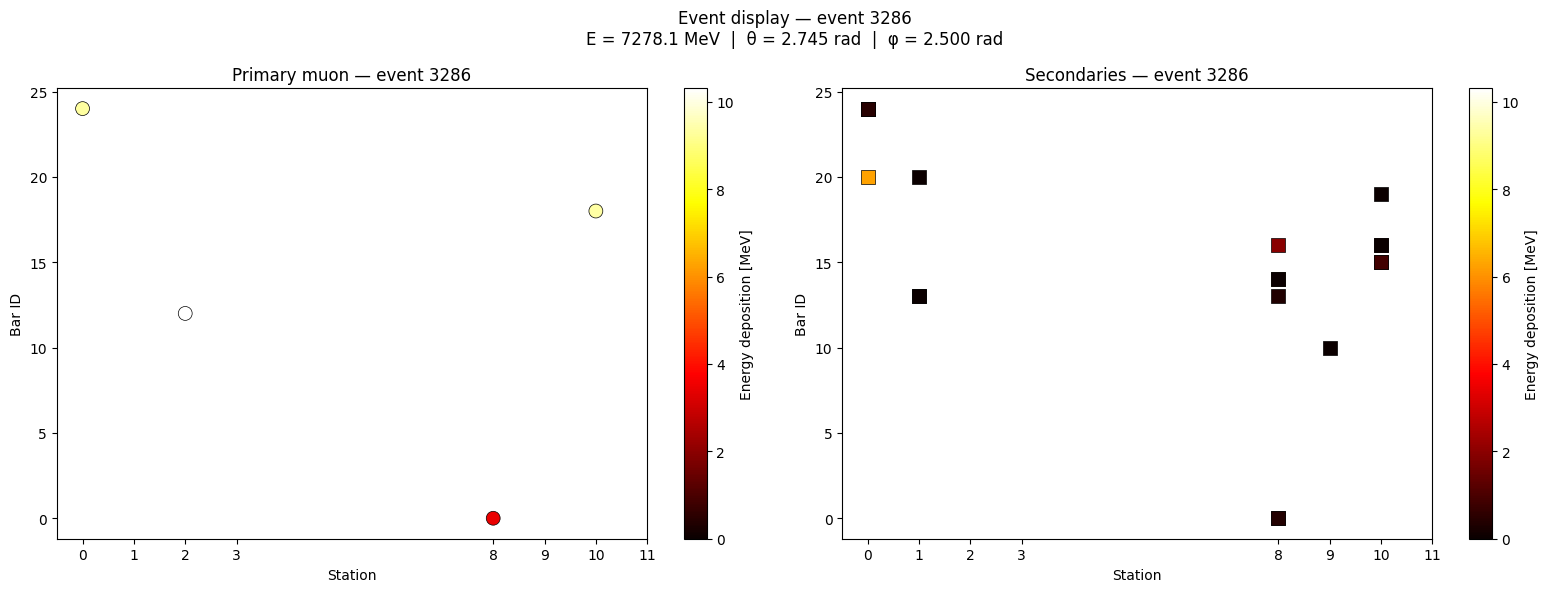

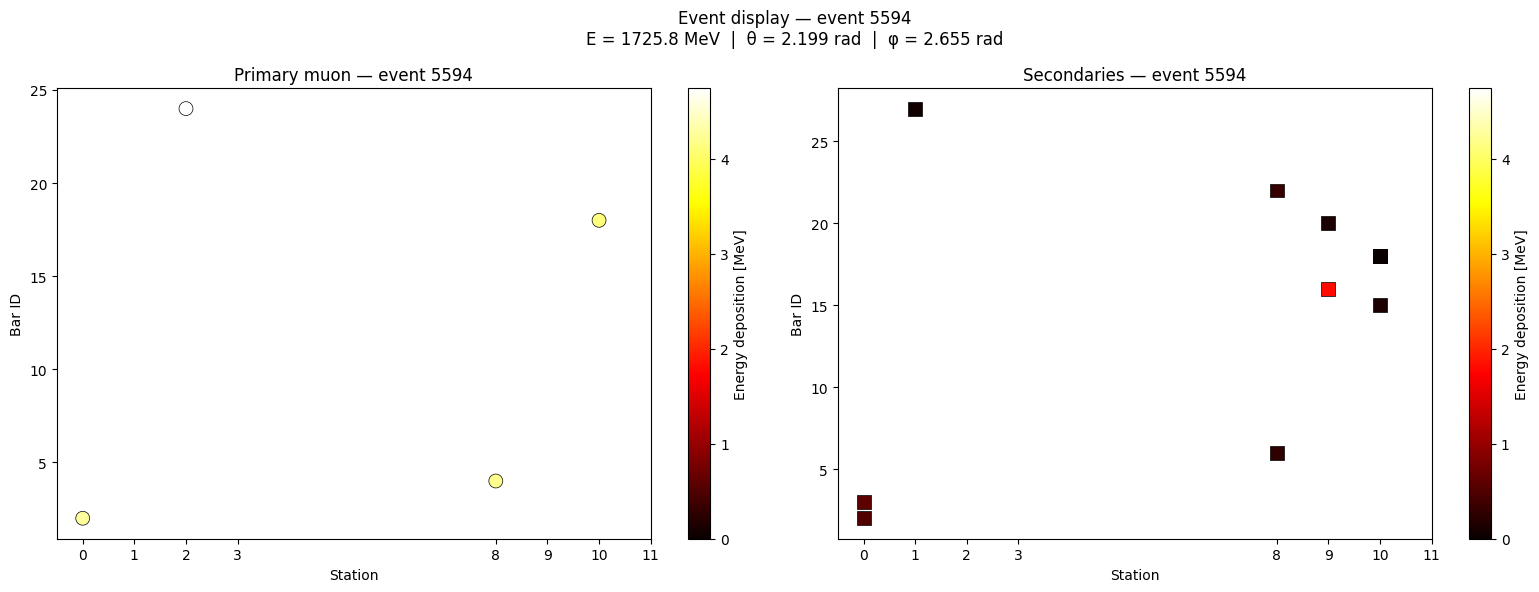

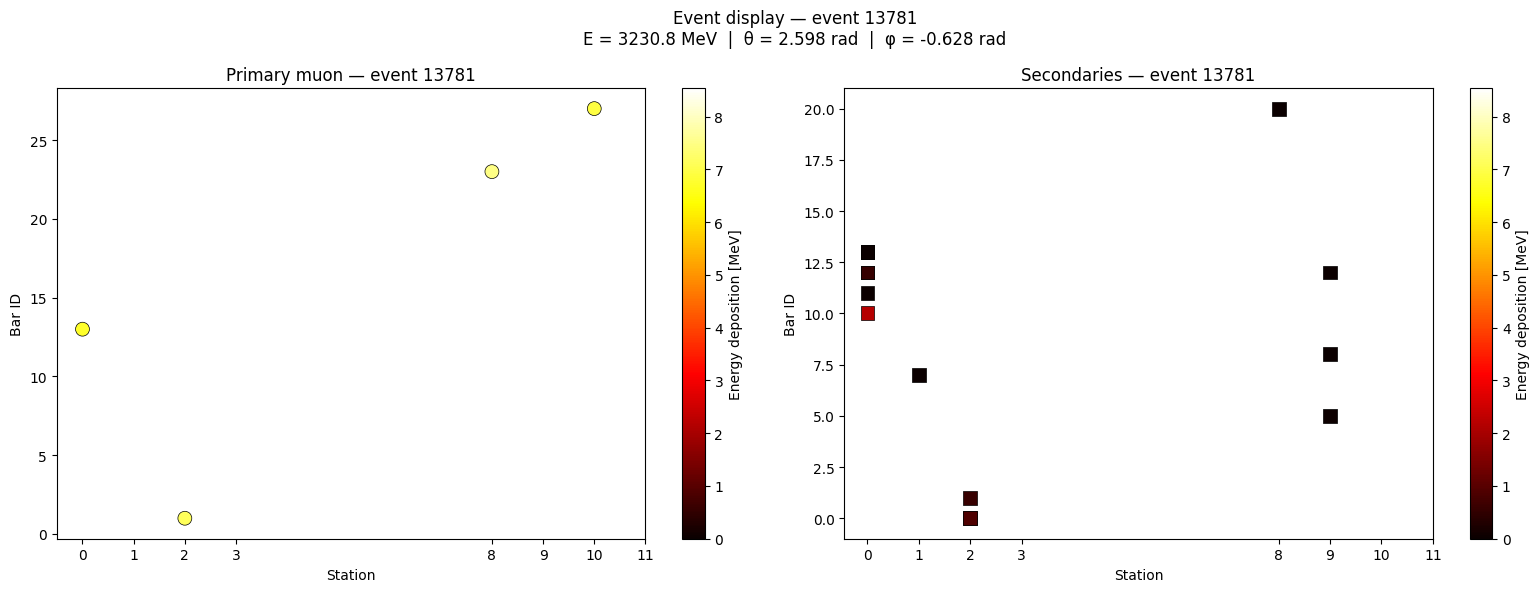

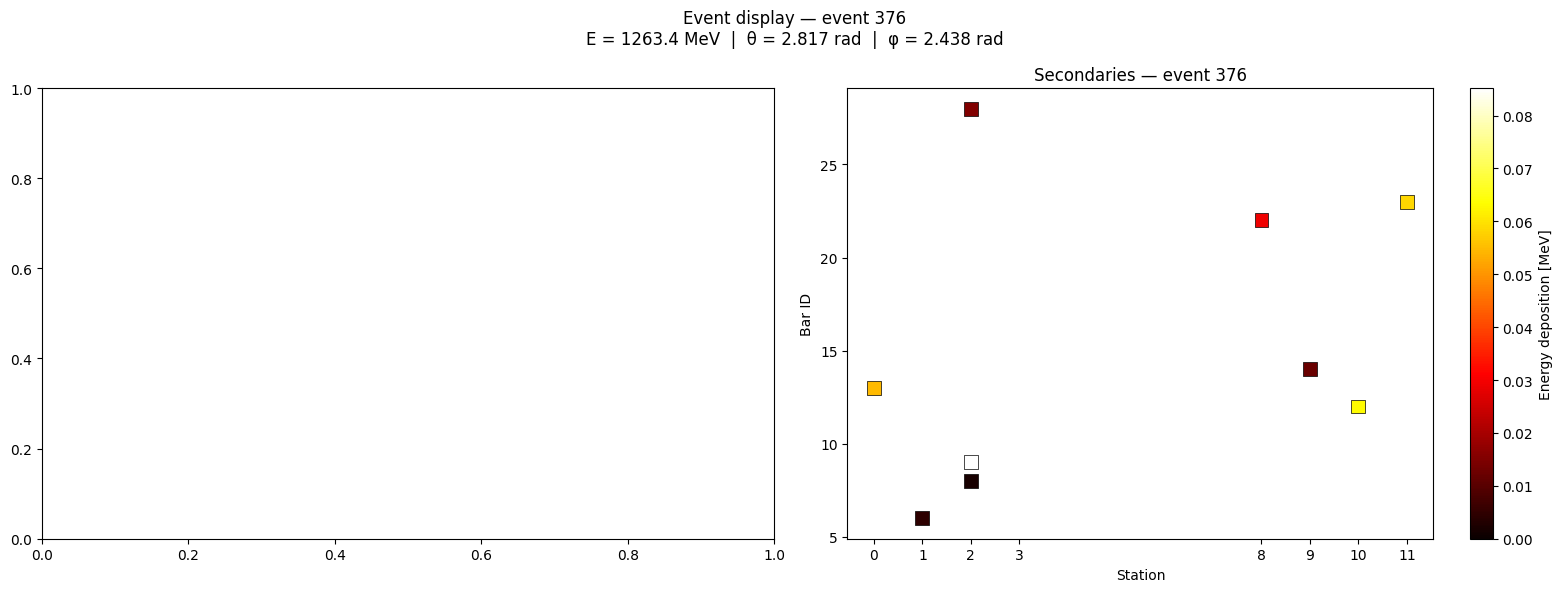

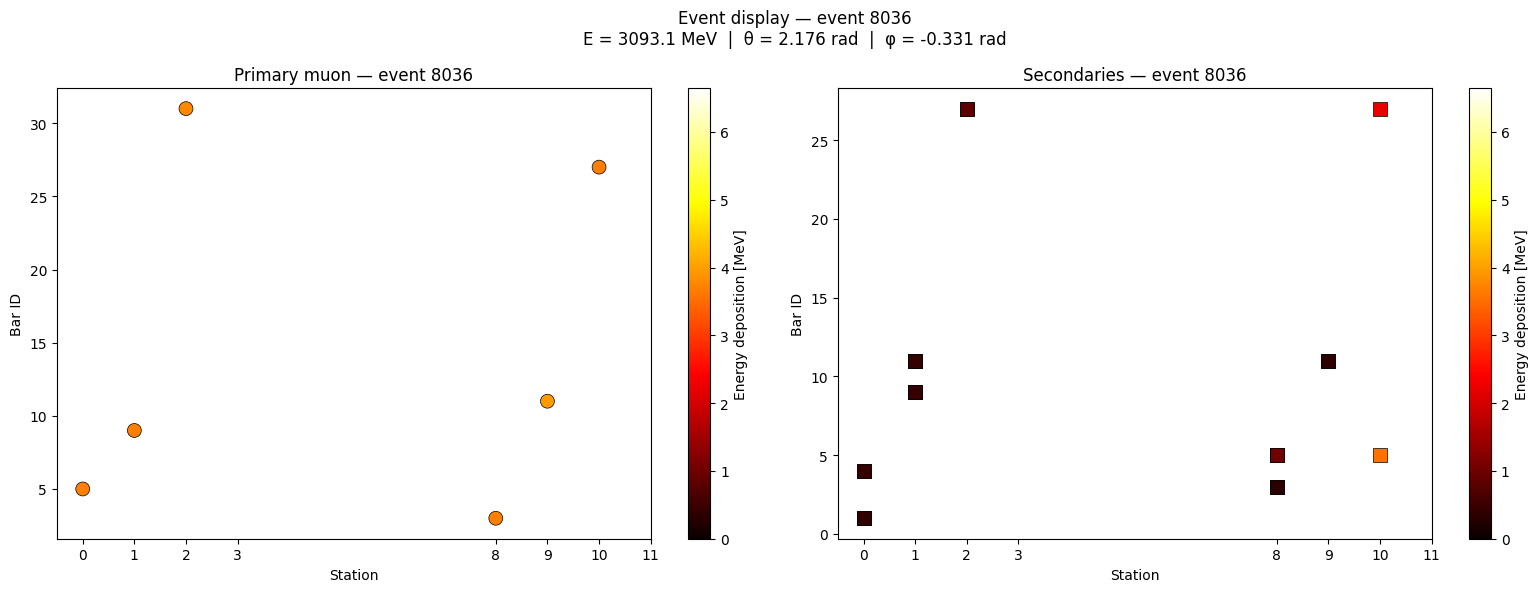

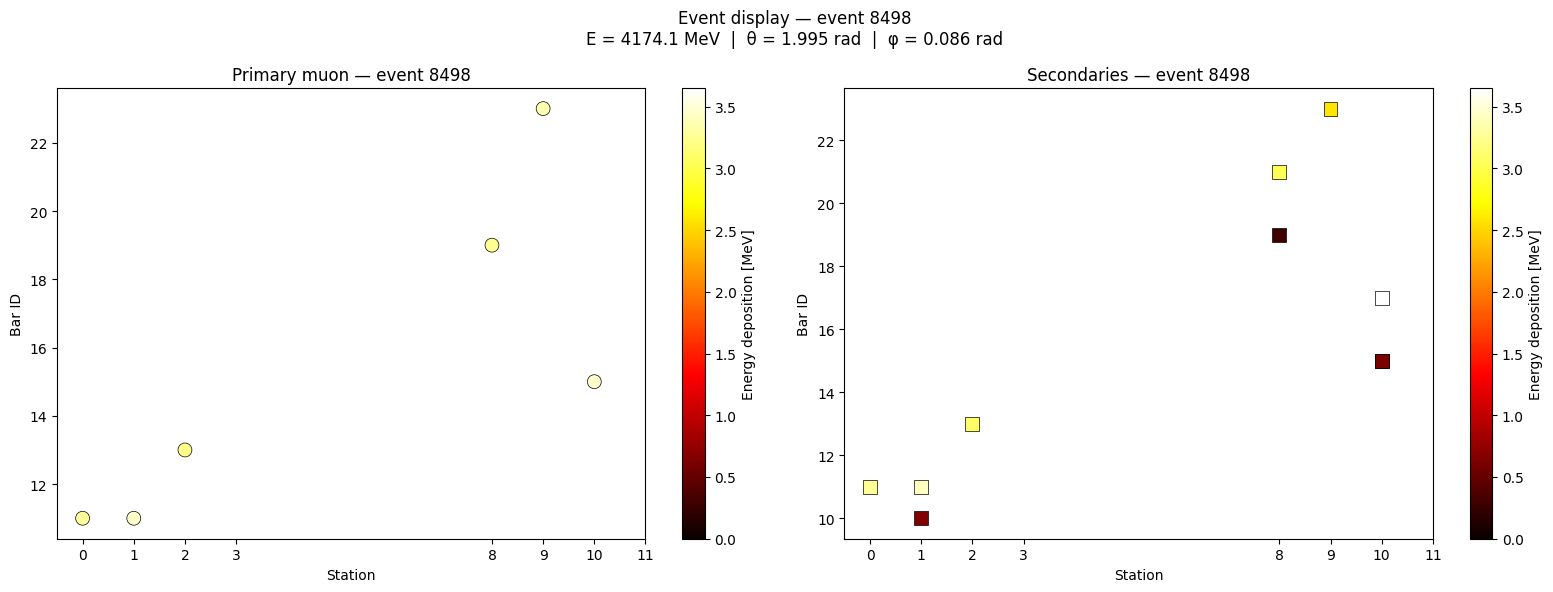

In [ ]:
# Inspect the problematic non-adjacent events
for event_id in list(non_adjacent_events)[:3]:
    plot_event_display(event_id)

# Or the secondary-dominated events
for event_id in list(secondary_dominated.index)[:3]:
    plot_event_display(event_id)

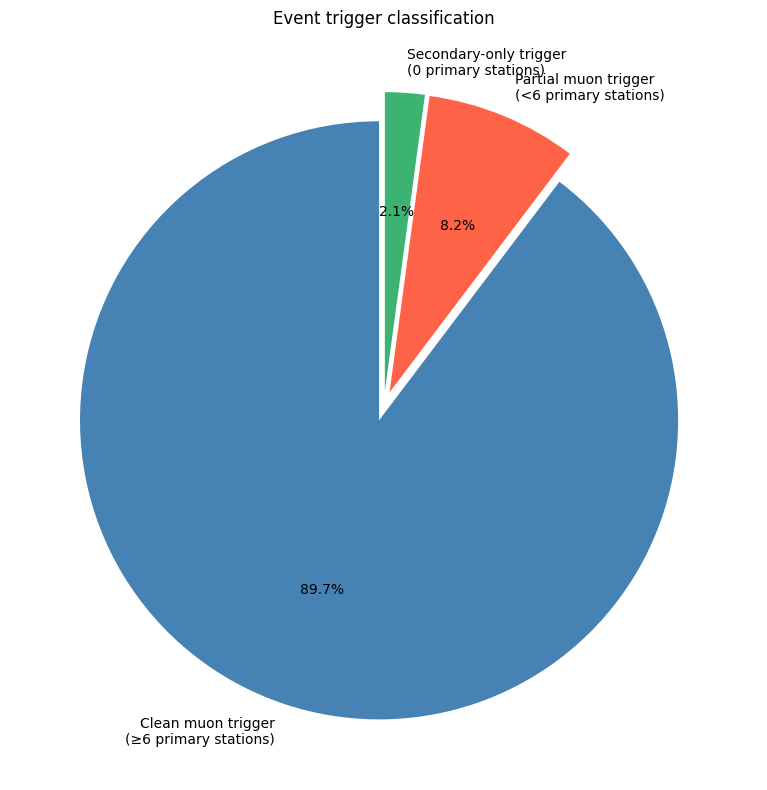

category
Clean muon trigger\n(≥6 primary stations)       1550
Partial muon trigger\n(<6 primary stations)      141
Secondary-only trigger\n(0 primary stations)      37
Name: count, dtype: int64


In [ ]:
# ── Classify events by trigger type ──────────────────────────────────────

# Number of stations hit by primary per event
primary_stations = (
    hit_df[hit_df["parent_id"] == 0]
    .groupby("event")["station"]
    .nunique()
    .reset_index(name="n_stations_primary")
)

# Number of stations hit by secondaries per event
secondary_stations = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby("event")["station"]
    .nunique()
    .reset_index(name="n_stations_secondary")
)

# Merge
event_class = primary_stations.merge(secondary_stations, on="event", how="outer").fillna(0)

# Classify
def classify_event(row):
    if row["n_stations_primary"] >= 6:
        return "Clean muon trigger\n(≥6 primary stations)"
    elif row["n_stations_primary"] > 0:
        return "Partial muon trigger\n(<6 primary stations)"
    else:
        return "Secondary-only trigger\n(0 primary stations)"

event_class["category"] = event_class.apply(classify_event, axis=1)

# Plot
counts  = event_class["category"].value_counts()
explode = [0.05] * len(counts)

plt.figure(figsize=(8, 8))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        startangle=90, explode=explode,
        colors=["steelblue", "tomato", "mediumseagreen"])
plt.title("Event trigger classification")
plt.tight_layout()
plt.show()

print(counts)

['event', 'n_stations_primary', 'n_stations_secondary', 'direction', 'edep', 'edep_class', 'n_sec', 'secondary_activity', 'n_hadronic', 'has_hadronic']


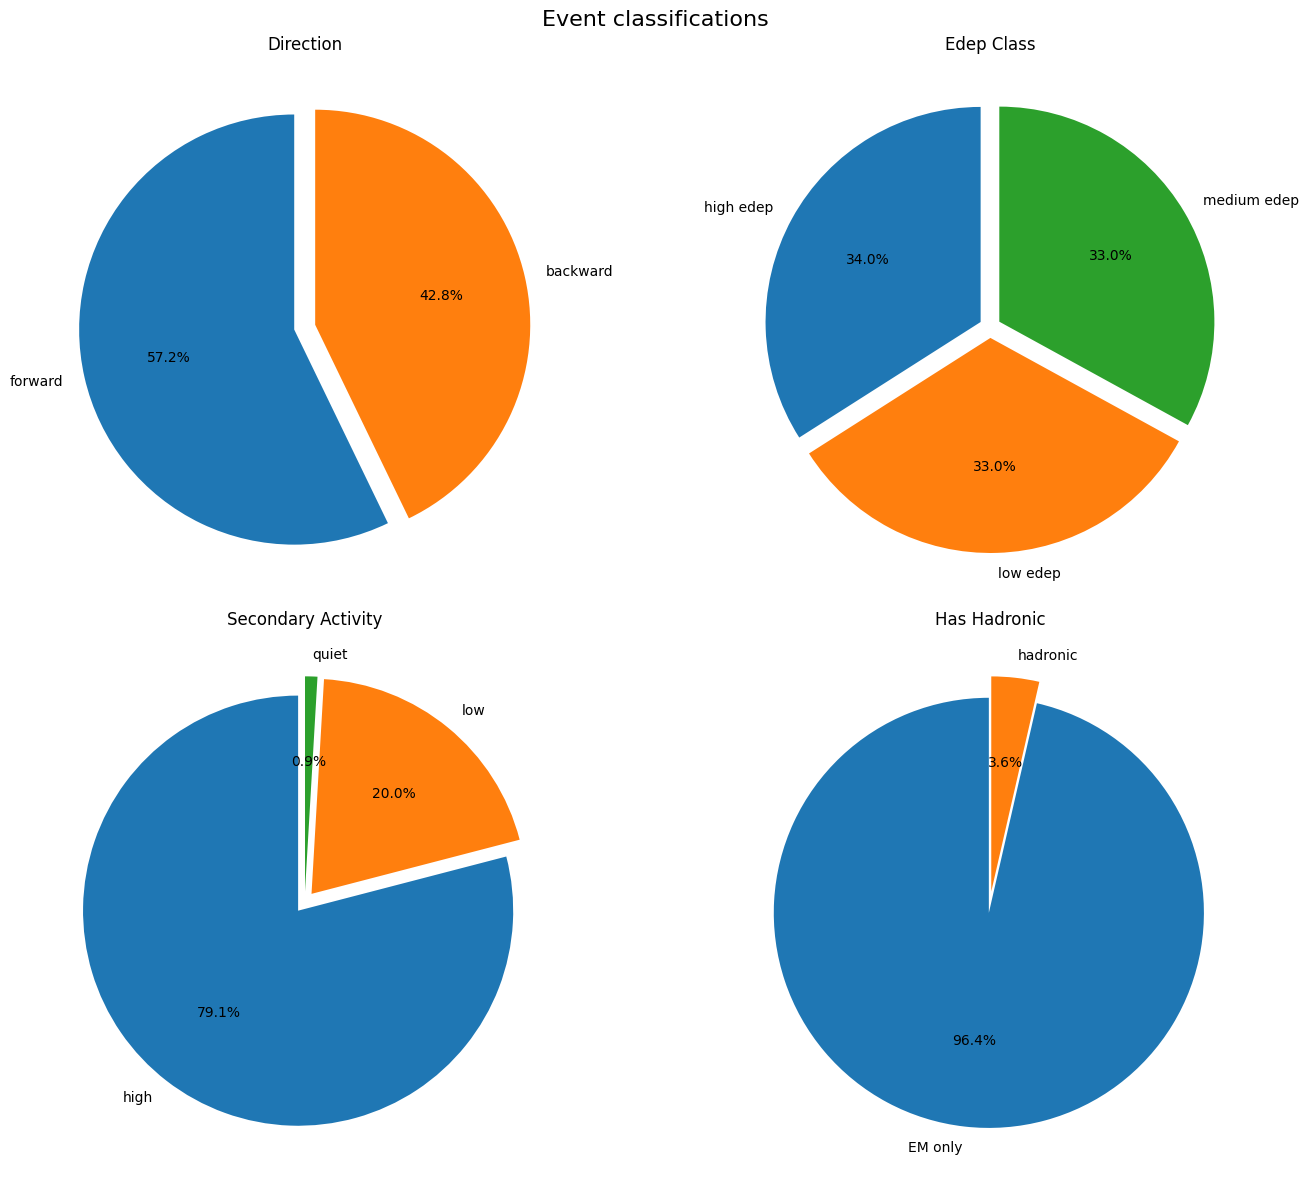

In [ ]:
# Start fresh from the base
event_class = primary_stations.merge(secondary_stations, on="event", how="outer").fillna(0)

# ── Direction ─────────────────────────────────────────────────────────────
direction = gen_df[["Event", "GenPartPhi"]].copy()
direction["direction"] = np.where(
    direction["GenPartPhi"].between(-np.pi/2, np.pi/2), "forward", "backward"
)
event_class = event_class.merge(
    direction[["Event", "direction"]],
    left_on="event", right_on="Event", how="left"
).drop(columns="Event")

# ── Energy deposition class ───────────────────────────────────────────────
edep_per_event = hit_df.groupby("event")["energy"].sum().reset_index(name="edep")
tertiles = edep_per_event["edep"].quantile([0.33, 0.66])
event_class = event_class.merge(edep_per_event, on="event", how="left")
event_class["edep_class"] = pd.cut(
    event_class["edep"],
    bins=[-np.inf, tertiles[0.33], tertiles[0.66], np.inf],
    labels=["low edep", "medium edep", "high edep"]
)

# ── Secondary activity ────────────────────────────────────────────────────
n_sec = (
    hit_df[hit_df["parent_id"] > 0]
    .groupby("event")["track_id"]
    .nunique()
    .reset_index(name="n_sec")
)
event_class = event_class.merge(n_sec, on="event", how="left").fillna({"n_sec": 0})
event_class["secondary_activity"] = pd.cut(
    event_class["n_sec"],
    bins=[-np.inf, 0, 3, np.inf],
    labels=["quiet", "low", "high"]
)

# ── Hadronic secondaries ──────────────────────────────────────────────────
hadronic_pdgs = [2212, 2112, 211, -211, 321, -321]
has_hadronic = (
    hit_df[hit_df["pdg"].isin(hadronic_pdgs)]
    .groupby("event")
    .size()
    .reset_index(name="n_hadronic")
)
event_class = event_class.merge(has_hadronic, on="event", how="left").fillna({"n_hadronic": 0})
event_class["has_hadronic"] = np.where(event_class["n_hadronic"] > 0, "hadronic", "EM only")

# ── Verify ────────────────────────────────────────────────────────────────
print(event_class.columns.tolist())

# ── Plot ──────────────────────────────────────────────────────────────────
categories = ["direction", "edep_class", "secondary_activity", "has_hadronic"]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, cat in zip(axes, categories):
    counts = event_class[cat].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
           startangle=90, explode=[0.05] * len(counts))
    ax.set_title(cat.replace("_", " ").title())

plt.suptitle("Event classifications", fontsize=16)
plt.tight_layout()
plt.show()

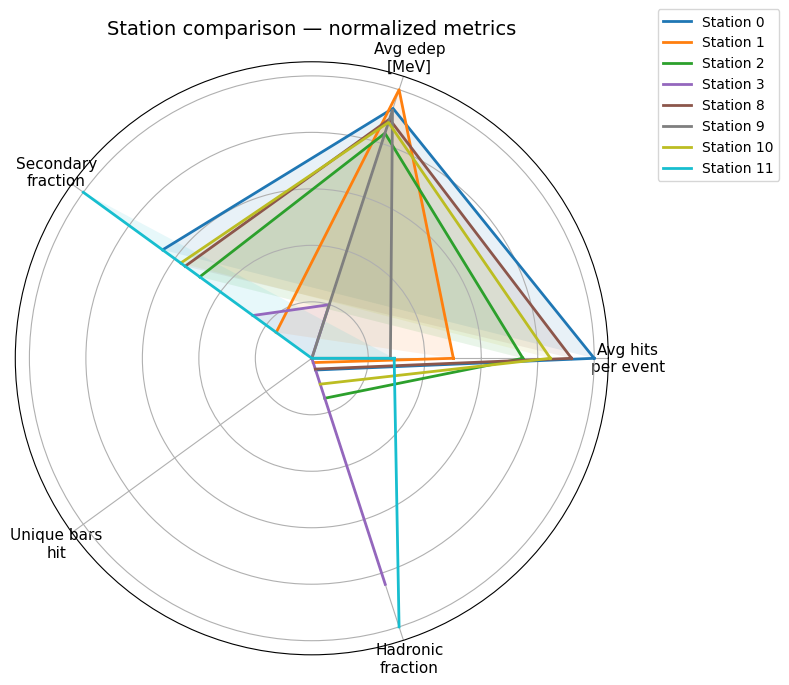

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Metrics per station ───────────────────────────────────────────────────
stations = sorted(hit_df["station"].unique())
n_stations = len(stations)

metrics = {
    "Avg hits\nper event":     hit_df.groupby(["event","station"]).size().groupby("station").mean(),
    "Avg edep\n[MeV]":         hit_df.groupby("station")["energy"].mean(),
    "Secondary\nfraction":     hit_df.groupby("station").apply(lambda x: (x["parent_id"] > 0).mean()),
    "Unique bars\nhit":        hit_df.groupby("station")["bar"].nunique(),
    "Hadronic\nfraction":      hit_df[hit_df["pdg"].isin([2212, 2112, 211, -211])].groupby("station").size() / hit_df.groupby("station").size(),
}

# Normalize each metric to [0, 1] for radar
df_radar = pd.DataFrame(metrics, index=stations).fillna(0)
df_radar_norm = (df_radar - df_radar.min()) / (df_radar.max() - df_radar.min())

# ── Radar chart ───────────────────────────────────────────────────────────
labels   = list(metrics.keys())
n_labels = len(labels)
angles   = np.linspace(0, 2 * np.pi, n_labels, endpoint=False).tolist()
angles  += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = plt.cm.tab10(np.linspace(0, 1, n_stations))

for i, station in enumerate(stations):
    values  = df_radar_norm.loc[station].tolist()
    values += values[:1]  # close the polygon
    ax.plot(angles, values, color=colors[i], linewidth=2, label=f"Station {station}")
    ax.fill(angles, values, color=colors[i], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_yticklabels([])
ax.set_title("Station comparison — normalized metrics", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

Forward  — mean secondaries per event: 7.71 ± 5.75
Backward — mean secondaries per event: 8.01 ± 9.90


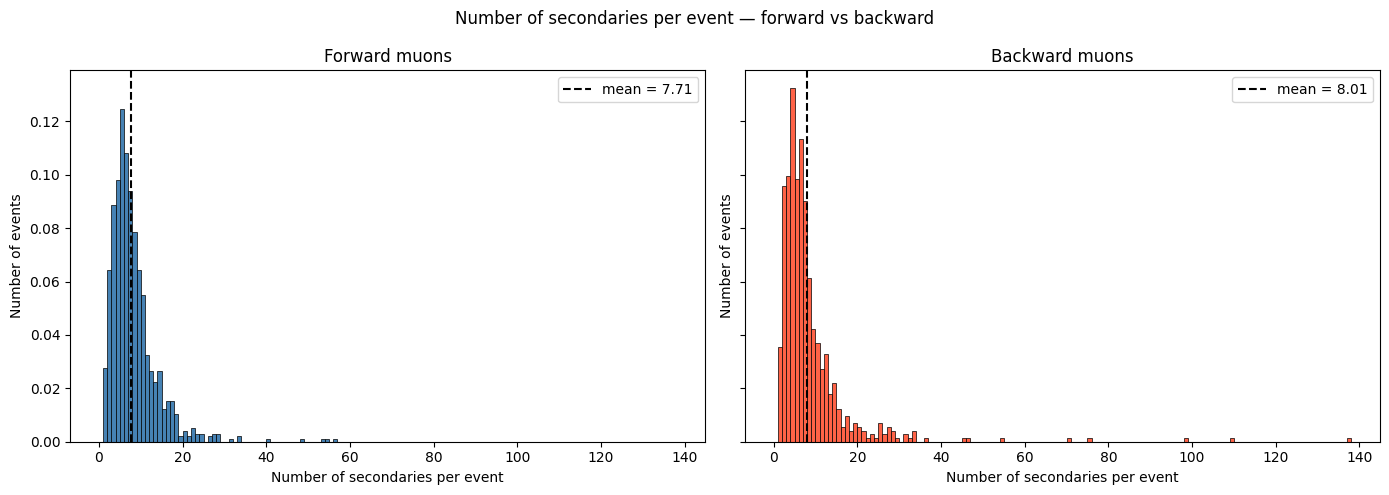

In [ ]:
forward_events  = gen_df[gen_df["GenPartPhi"].between(-np.pi/2,  np.pi/2)]["Event"]
backward_events = gen_df[~gen_df["GenPartPhi"].between(-np.pi/2, np.pi/2)]["Event"]

hits_forward  = hit_df[hit_df["event"].isin(forward_events)]
hits_backward = hit_df[hit_df["event"].isin(backward_events)]

# Number of unique secondary tracks per event
n_sec_forward = (
    hits_forward[hits_forward["parent_id"] > 0]
    .groupby("event")["track_id"]
    .nunique()
)
n_sec_backward = (
    hits_backward[hits_backward["parent_id"] > 0]
    .groupby("event")["track_id"]
    .nunique()
)

print(f"Forward  — mean secondaries per event: {n_sec_forward.mean():.2f} ± {n_sec_forward.std():.2f}")
print(f"Backward — mean secondaries per event: {n_sec_backward.mean():.2f} ± {n_sec_backward.std():.2f}")

max_val = max(n_sec_forward.max(), n_sec_backward.max())
bins = np.arange(0, max_val + 2, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, label, color in zip(
    axes,
    [n_sec_forward, n_sec_backward],
    ["Forward", "Backward"],
    ["steelblue", "tomato"]
):
    ax.hist(data, bins=bins, color=color, edgecolor="black", linewidth=0.5, density=True)
    ax.axvline(data.mean(), color="black", linestyle="--",
               label=f"mean = {data.mean():.2f}")
    ax.set_xlabel("Number of secondaries per event")
    ax.set_ylabel("Number of events")
    ax.set_title(f"{label} muons")
    ax.legend()

plt.suptitle("Number of secondaries per event — forward vs backward")
plt.tight_layout()
plt.show()

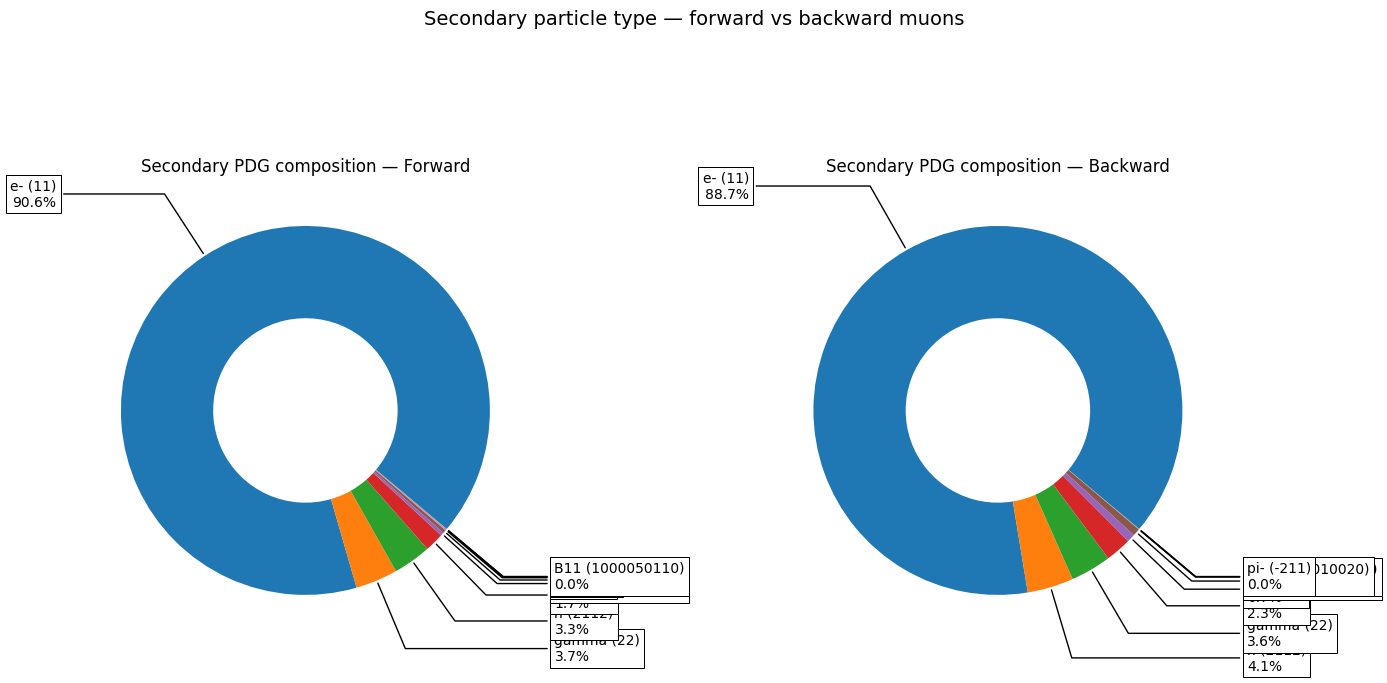

In [ ]:
# ── Secondary PDG composition — forward vs backward ───────────────────────

sec_forward  = hits_forward[hits_forward["parent_id"] > 0]
sec_backward = hits_backward[hits_backward["parent_id"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, data, label in zip(
    axes,
    [sec_forward, sec_backward],
    ["Forward", "Backward"]
):
    pdg_counts  = data["pdg"].value_counts()
    pdg_percent = data["pdg"].value_counts(normalize=True) * 100

    labels_with_pct = [f"{pdg_to_name(p)} ({p})\n{pct:.1f}%"
                       for p, pct in zip(pdg_percent.index, pdg_percent.values)]

    wedges, texts = ax.pie(
        pdg_percent.values,
        wedgeprops=dict(width=0.5),
        startangle=-40
    )

    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(labels_with_pct[i], xy=(x, y),
                    xytext=(1.35 * np.sign(x), 1.4 * y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title(f"Secondary PDG composition — {label}")

plt.suptitle("Secondary particle type — forward vs backward muons", fontsize=14)
plt.tight_layout()
plt.show()

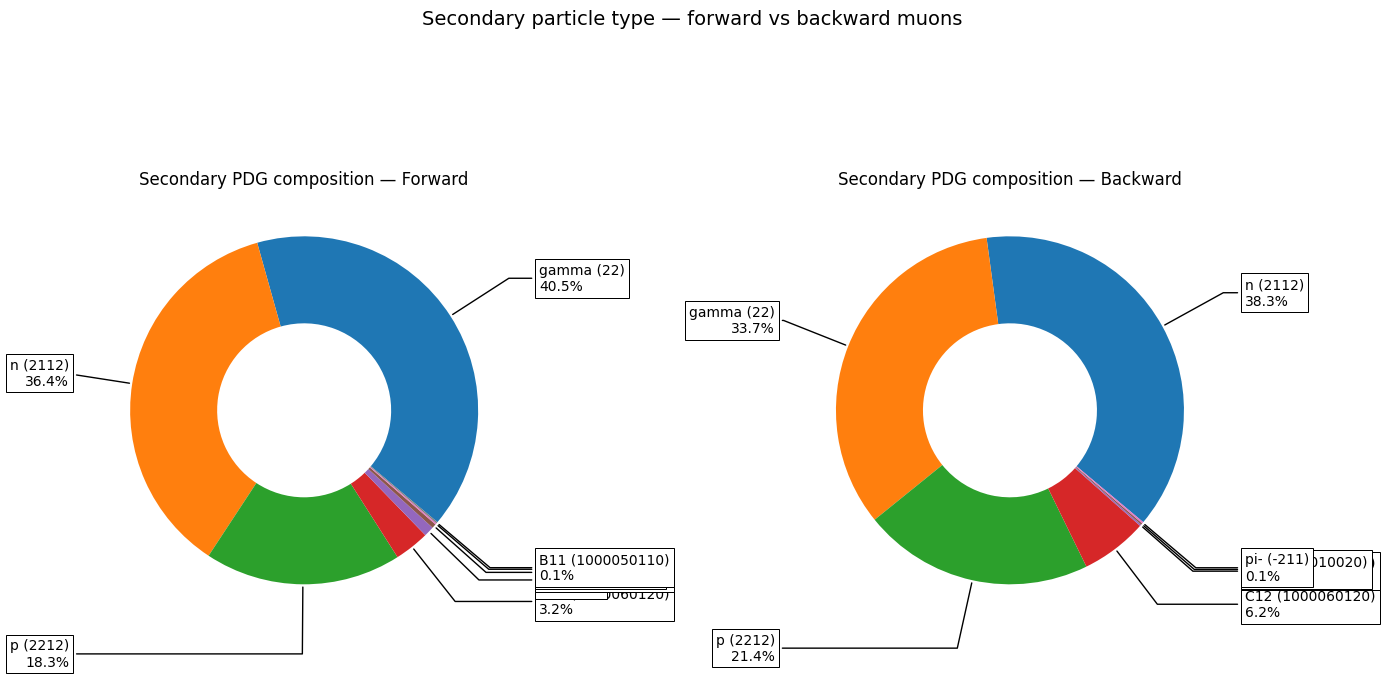

In [306]:
sec_forward_filtered  = hits_forward[(hits_forward["parent_id"] > 0)  & (~hits_forward["pdg"].isin([11, -11]))]
sec_backward_filtered = hits_backward[(hits_backward["parent_id"] > 0) & (~hits_backward["pdg"].isin([11, -11]))]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, data, label in zip(
    axes,
    [sec_forward_filtered, sec_backward_filtered],
    ["Forward", "Backward"]
):
    pdg_counts  = data["pdg"].value_counts()
    pdg_percent = data["pdg"].value_counts(normalize=True) * 100

    labels_with_pct = [f"{pdg_to_name(p)} ({p})\n{pct:.1f}%"
                       for p, pct in zip(pdg_percent.index, pdg_percent.values)]

    wedges, texts = ax.pie(
        pdg_percent.values,
        wedgeprops=dict(width=0.5),
        startangle=-40
    )

    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(labels_with_pct[i], xy=(x, y),
                    xytext=(1.35 * np.sign(x), 1.4 * y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title(f"Secondary PDG composition — {label}")

plt.suptitle("Secondary particle type — forward vs backward muons", fontsize=14)
plt.tight_layout()
plt.show()

In [293]:
forward_events  = gen_df[gen_df["GenPartPhi"].between(-np.pi/2,  np.pi/2)]["Event"]
backward_events = gen_df[~gen_df["GenPartPhi"].between(-np.pi/2, np.pi/2)]["Event"]

hits_forward  = hit_df[hit_df["event"].isin(forward_events)]
hits_backward = hit_df[hit_df["event"].isin(backward_events)]

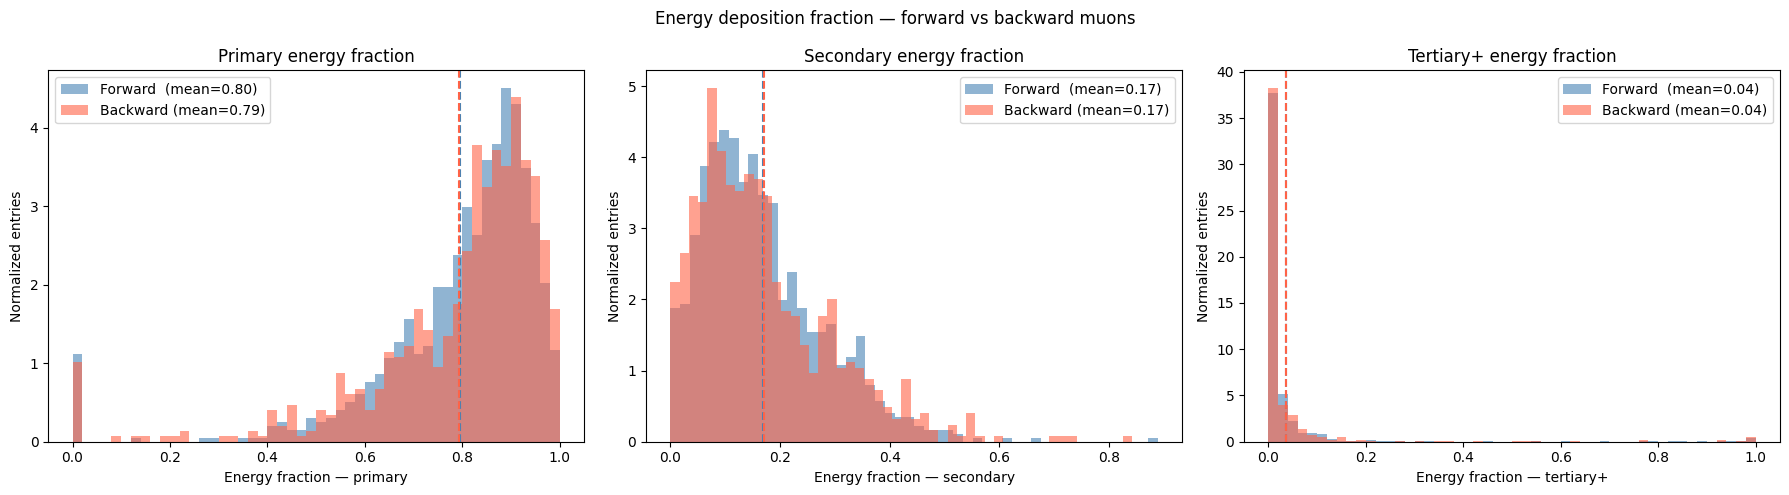

In [294]:
def edep_fractions(hits):
    edep = (
        hits.groupby(["event", "generation"])["energy"]
        .sum()
        .reset_index(name="edep")
    )
    pivot = edep.pivot_table(index="event", columns="generation", 
                             values="edep", fill_value=0)
    pivot["total"] = pivot.sum(axis=1)
    for gen in ["primary", "secondary", "tertiary+"]:
        if gen in pivot.columns:
            pivot[f"frac_{gen}"] = pivot[gen] / pivot["total"]
    return pivot

frac_forward  = edep_fractions(hits_forward)
frac_backward = edep_fractions(hits_backward)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (gen, color) in zip(axes, zip(
    ["primary", "secondary", "tertiary+"],
    ["steelblue", "tomato", "mediumseagreen"]
)):
    col = f"frac_{gen}"
    if col not in frac_forward.columns or col not in frac_backward.columns:
        continue

    ax.hist(frac_forward[col],  bins=50, alpha=0.6, density=True,
            color="steelblue", label=f"Forward  (mean={frac_forward[col].mean():.2f})")
    ax.hist(frac_backward[col], bins=50, alpha=0.6, density=True,
            color="tomato",    label=f"Backward (mean={frac_backward[col].mean():.2f})")
    ax.axvline(frac_forward[col].mean(),  color="steelblue", linestyle="--")
    ax.axvline(frac_backward[col].mean(), color="tomato",    linestyle="--")
    ax.set_xlabel(f"Energy fraction — {gen}")
    ax.set_ylabel("Normalized entries")
    ax.set_title(f"{gen.capitalize()} energy fraction")
    ax.legend()

plt.suptitle("Energy deposition fraction — forward vs backward muons")
plt.tight_layout()
plt.show()

Forward  — mean edep: 32.18 ± 11.15 MeV
Backward — mean edep: 31.17 ± 15.25 MeV


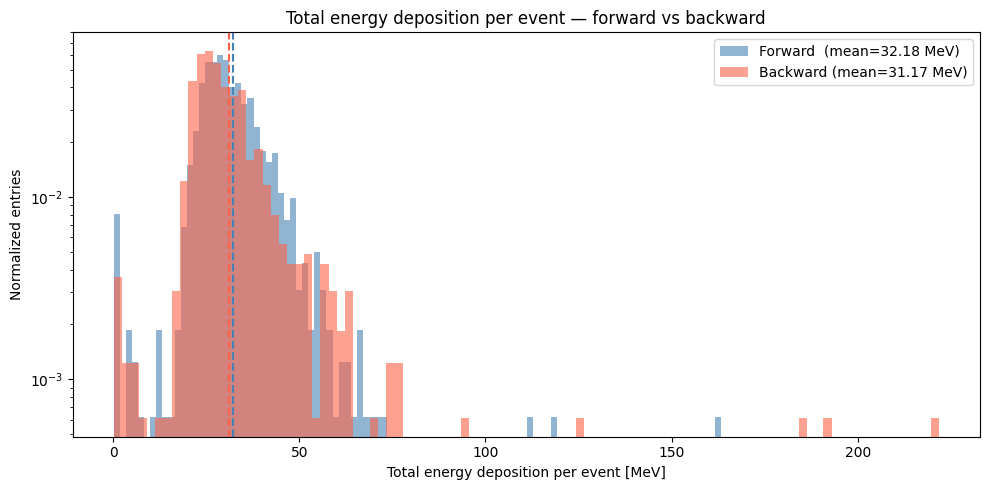

In [295]:
# ── 1. Total energy deposition per event — forward vs backward ────────────

edep_forward  = hits_forward.groupby("event")["energy"].sum()
edep_backward = hits_backward.groupby("event")["energy"].sum()

print(f"Forward  — mean edep: {edep_forward.mean():.2f} ± {edep_forward.std():.2f} MeV")
print(f"Backward — mean edep: {edep_backward.mean():.2f} ± {edep_backward.std():.2f} MeV")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(edep_forward,  bins=100, alpha=0.6, density=True, color="steelblue",
        label=f"Forward  (mean={edep_forward.mean():.2f} MeV)")
ax.hist(edep_backward, bins=100, alpha=0.6, density=True, color="tomato",
        label=f"Backward (mean={edep_backward.mean():.2f} MeV)")
ax.axvline(edep_forward.mean(),  color="steelblue", linestyle="--")
ax.axvline(edep_backward.mean(), color="tomato",    linestyle="--")
ax.set_xlabel("Total energy deposition per event [MeV]")
ax.set_ylabel("Normalized entries")
ax.set_title("Total energy deposition per event — forward vs backward")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

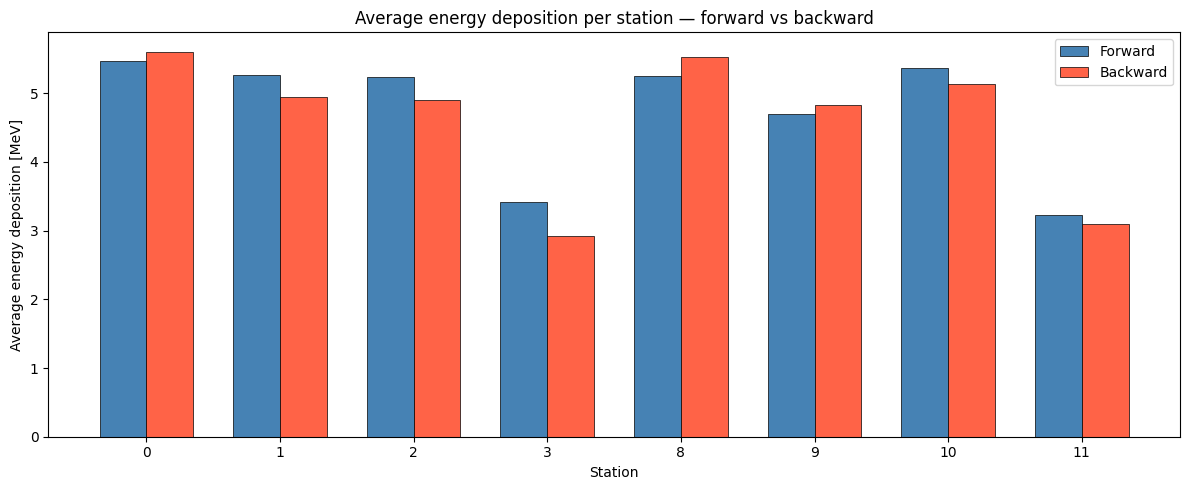

In [296]:
# ── 2. Energy deposition per station — forward vs backward ────────────────

edep_station_forward = (
    hits_forward.groupby(["event", "station"])["energy"]
    .sum()
    .groupby("station")
    .mean()
)
edep_station_backward = (
    hits_backward.groupby(["event", "station"])["energy"]
    .sum()
    .groupby("station")
    .mean()
)

stations = sorted(hit_df["station"].unique())
x = np.arange(len(stations))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, edep_station_forward.values,  width, color="steelblue",
       edgecolor="black", linewidth=0.5, label="Forward")
ax.bar(x + width/2, edep_station_backward.values, width, color="tomato",
       edgecolor="black", linewidth=0.5, label="Backward")
ax.set_xlabel("Station")
ax.set_ylabel("Average energy deposition [MeV]")
ax.set_title("Average energy deposition per station — forward vs backward")
ax.set_xticks(x)
ax.set_xticklabels(stations)
ax.legend()
plt.tight_layout()
plt.show()

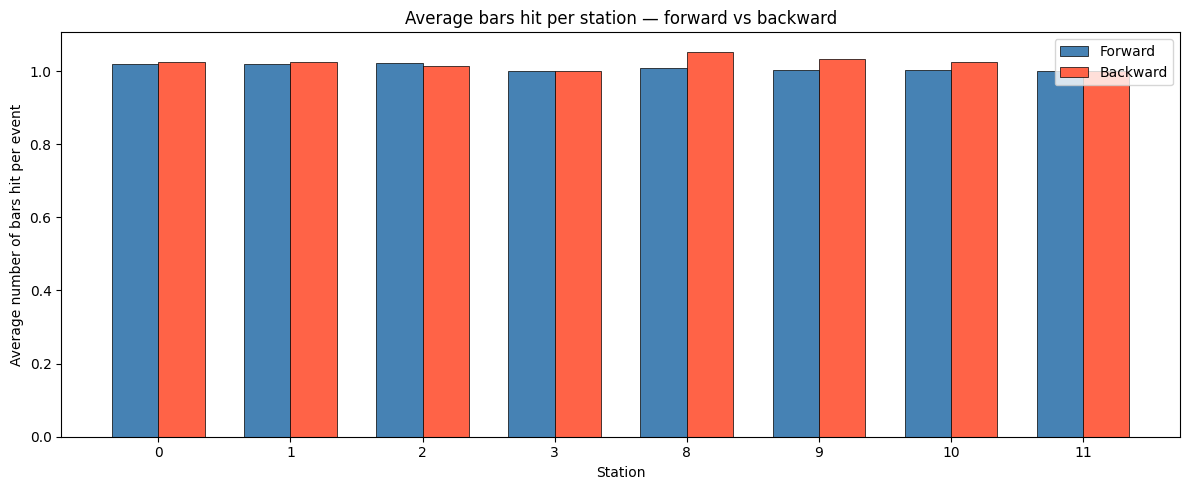

In [298]:
# ── 4. Number of bars hit per station — forward vs backward ──────────────

bars_forward = (
    hits_forward[hits_forward["parent_id"] == 0]
    .groupby(["event", "station"])["bar"]
    .nunique()
    .groupby("station")
    .mean()
)
bars_backward = (
    hits_backward[hits_backward["parent_id"] == 0]
    .groupby(["event", "station"])["bar"]
    .nunique()
    .groupby("station")
    .mean()
)

stations = sorted(hit_df["station"].unique())
x = np.arange(len(stations))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, bars_forward.values,  width, color="steelblue",
       edgecolor="black", linewidth=0.5, label="Forward")
ax.bar(x + width/2, bars_backward.values, width, color="tomato",
       edgecolor="black", linewidth=0.5, label="Backward")
ax.set_xlabel("Station")
ax.set_ylabel("Average number of bars hit per event")
ax.set_title("Average bars hit per station — forward vs backward")
ax.set_xticks(x)
ax.set_xticklabels(stations)
ax.legend()
plt.tight_layout()
plt.show()

Forward  — mean energy: 9121.10 ± 24492.61 MeV
Backward — mean energy: 11575.31 ± 38185.69 MeV


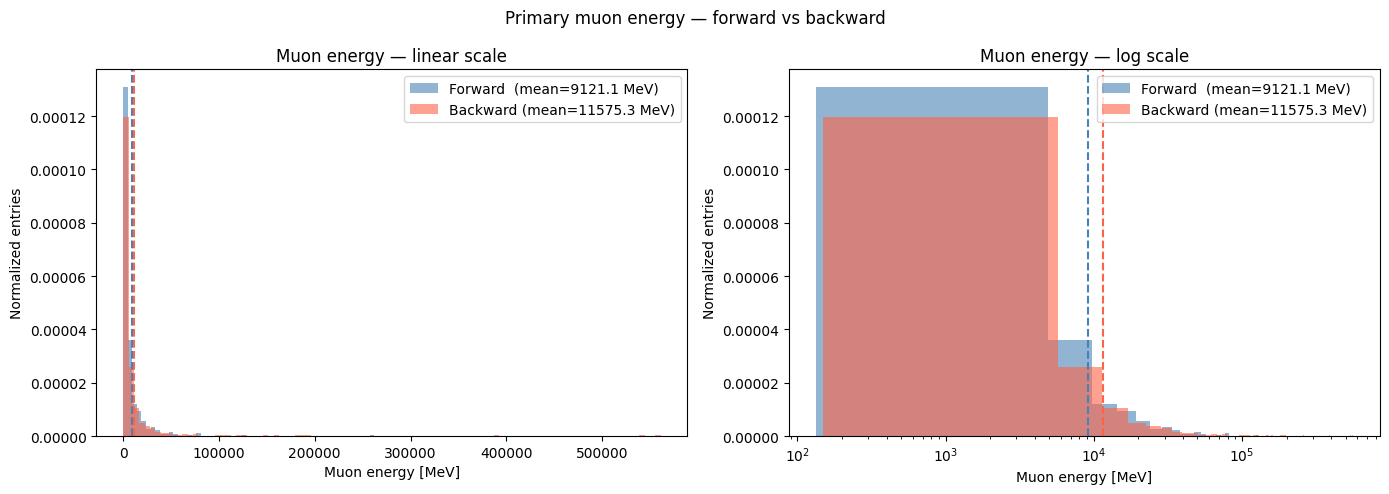

In [301]:
# ── Primary muon energy — forward vs backward ─────────────────────────────

energy_forward  = gen_df[gen_df["Event"].isin(forward_events)]["GenPartE"]
energy_backward = gen_df[gen_df["Event"].isin(backward_events)]["GenPartE"]

print(f"Forward  — mean energy: {energy_forward.mean():.2f} ± {energy_forward.std():.2f} MeV")
print(f"Backward — mean energy: {energy_backward.mean():.2f} ± {energy_backward.std():.2f} MeV")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(energy_forward,  bins=100, alpha=0.6, density=True, color="steelblue",
             label=f"Forward  (mean={energy_forward.mean():.1f} MeV)")
axes[0].hist(energy_backward, bins=100, alpha=0.6, density=True, color="tomato",
             label=f"Backward (mean={energy_backward.mean():.1f} MeV)")
axes[0].axvline(energy_forward.mean(),  color="steelblue", linestyle="--")
axes[0].axvline(energy_backward.mean(), color="tomato",    linestyle="--")
axes[0].set_xlabel("Muon energy [MeV]")
axes[0].set_ylabel("Normalized entries")
axes[0].set_title("Muon energy — linear scale")
axes[0].legend()

# Log scale — better for wide energy ranges
axes[1].hist(energy_forward,  bins=100, alpha=0.6, density=True, color="steelblue",
             label=f"Forward  (mean={energy_forward.mean():.1f} MeV)")
axes[1].hist(energy_backward, bins=100, alpha=0.6, density=True, color="tomato",
             label=f"Backward (mean={energy_backward.mean():.1f} MeV)")
axes[1].axvline(energy_forward.mean(),  color="steelblue", linestyle="--")
axes[1].axvline(energy_backward.mean(), color="tomato",    linestyle="--")
axes[1].set_xlabel("Muon energy [MeV]")
axes[1].set_ylabel("Normalized entries")
axes[1].set_title("Muon energy — log scale")
axes[1].set_xscale("log")
axes[1].legend()

plt.suptitle("Primary muon energy — forward vs backward")
plt.tight_layout()
plt.show()

  direction   mean_energy  mean_edep  mean_n_sec  mean_n_stations  \
0   forward   9121.097205  32.180957    7.710204         6.063147   
1  backward  11575.309958  31.174323    8.013661         5.852414   

   mean_n_bars  mean_theta  
0    15.710189    2.201383  
1    15.630699    2.154915  


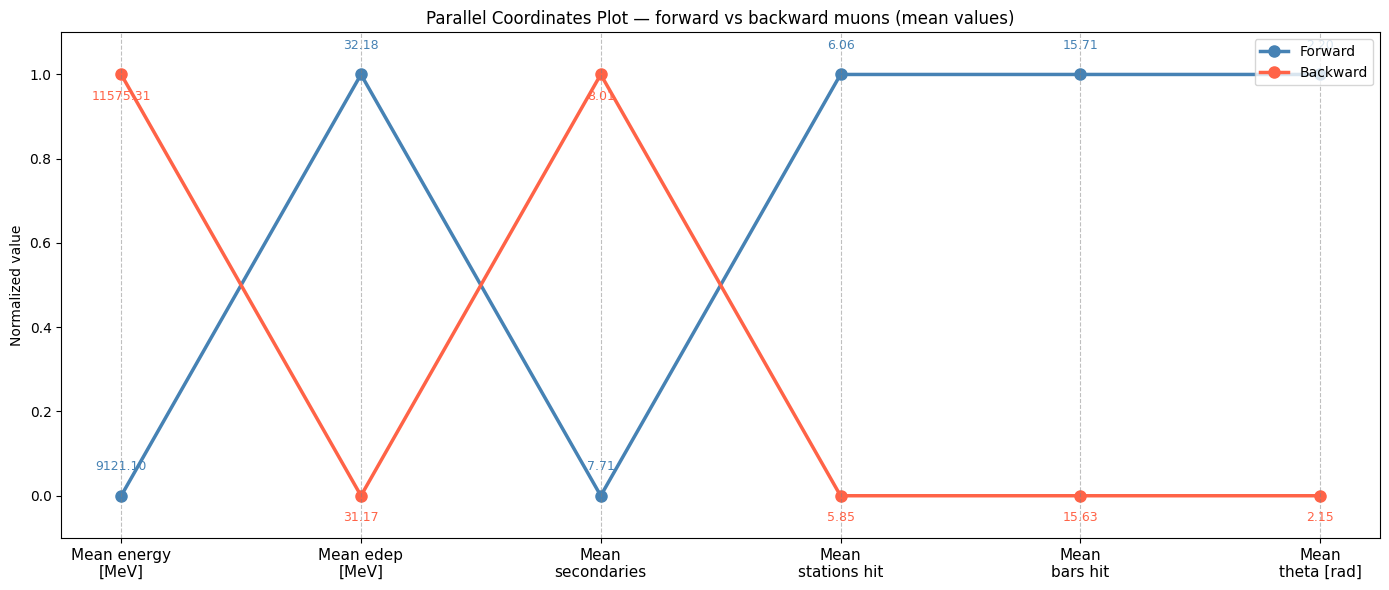

In [ ]:
from matplotlib.path import Path
import matplotlib.patches as mpatches

# ── Build summary dataframe ───────────────────────────────────────────────

summary = pd.DataFrame({
    "direction":        ["forward", "backward"],
    "mean_energy":      [energy_forward.mean(),           energy_backward.mean()],
    "mean_edep":        [edep_forward.mean(),              edep_backward.mean()],
    "mean_n_sec":       [n_sec_forward.mean(),             n_sec_backward.mean()],
    "mean_n_stations":  [stations_forward.mean(),          stations_backward.mean()],
    "mean_n_bars":      [bars_forward_dist.mean(),         bars_backward_dist.mean()],
    "mean_theta":       [gen_df[gen_df["Event"].isin(forward_events)]["GenPartTheta"].mean(),
                         gen_df[gen_df["Event"].isin(backward_events)]["GenPartTheta"].mean()],
})

print(summary)

# ── Normalize each variable to [0, 1] for plotting ───────────────────────
vars_to_plot = ["mean_energy", "mean_edep", "mean_n_sec", 
                "mean_n_stations", "mean_n_bars", "mean_theta"]

labels = ["Mean energy\n[MeV]", "Mean edep\n[MeV]", "Mean\nsecondaries",
          "Mean\nstations hit", "Mean\nbars hit", "Mean\ntheta [rad]"]

df_norm = summary.copy()
for var in vars_to_plot:
    min_val = summary[var].min()
    max_val = summary[var].max()
    if max_val != min_val:
        df_norm[var] = (summary[var] - min_val) / (max_val - min_val)
    else:
        df_norm[var] = 0.5

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"forward": "steelblue", "backward": "tomato"}
n_vars = len(vars_to_plot)
x = np.arange(n_vars)

for _, row in df_norm.iterrows():
    y = [row[var] for var in vars_to_plot]
    ax.plot(x, y, color=colors[row["direction"]], linewidth=2.5,
            marker="o", markersize=8, label=row["direction"])

# Axis labels and actual values as ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Normalized value")
ax.set_ylim(-0.1, 1.1)

# Add actual values as annotations
for _, row in summary.iterrows():
    for i, var in enumerate(vars_to_plot):
        val = row[var]
        offset = 0.06 if row["direction"] == "forward" else -0.06
        ax.annotate(f"{val:.2f}",
                    xy=(i, df_norm.loc[df_norm["direction"] == row["direction"], var].values[0]),
                    xytext=(i, df_norm.loc[df_norm["direction"] == row["direction"], var].values[0] + offset),
                    ha="center", fontsize=9,
                    color=colors[row["direction"]])

# Draw vertical axes
for xi in x:
    ax.axvline(xi, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.legend(["Forward", "Backward"], loc="upper right")
ax.set_title("Parallel Coordinates Plot — forward vs backward muons (mean values)")
plt.tight_layout()
plt.show()

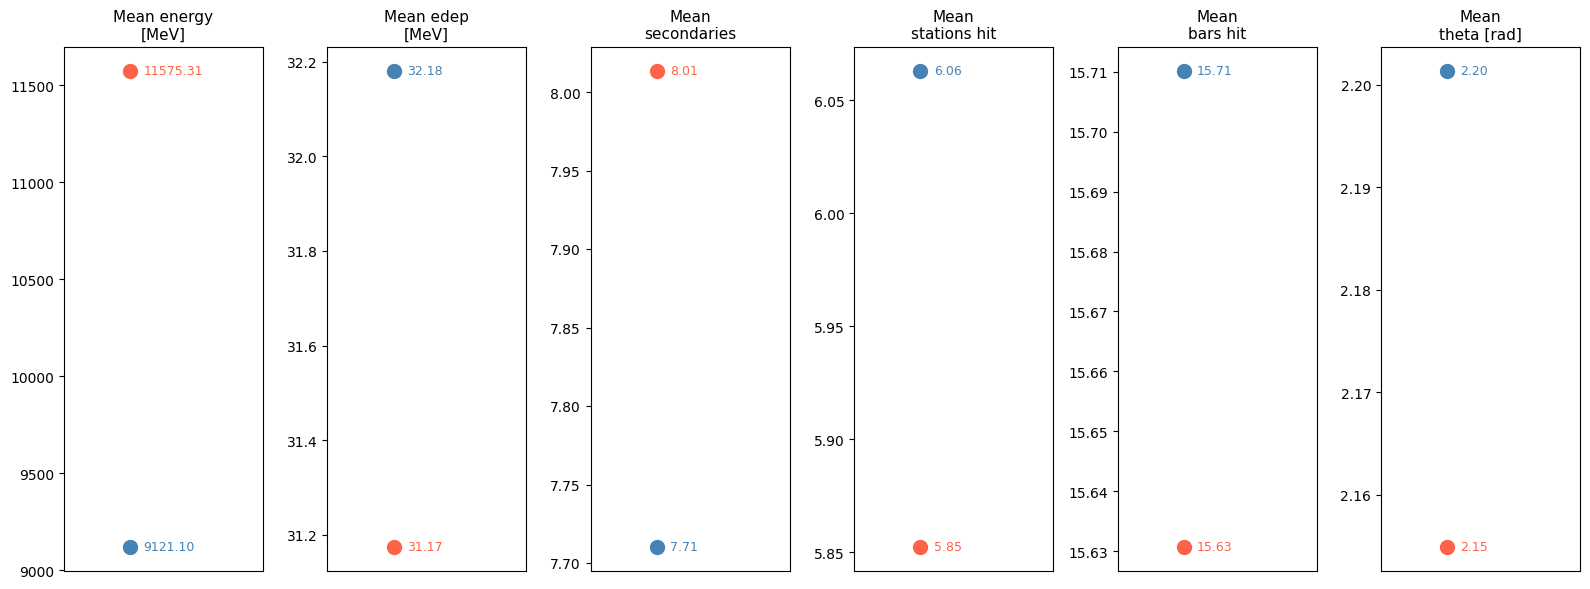

In [304]:
pythonfig, axes = plt.subplots(1, len(vars_to_plot), figsize=(16, 6), sharey=False)

colors = {"forward": "steelblue", "backward": "tomato"}

for i, (ax, var, label) in enumerate(zip(axes, vars_to_plot, labels)):
    for _, row in summary.iterrows():
        ax.plot(0, row[var], color=colors[row["direction"]],
                marker="o", markersize=10)
        ax.annotate(f"{row[var]:.2f}",
                    xy=(0, row[var]),
                    xytext=(0.1, row[var]),
                    fontsize=9, color=colors[row["direction"]],
                    va="center")
    ax.set_xticks([])
    ax.set_title(label, fontsize=11)
    ax.set_xlim(-0.5, 1)

# Draw connecting lines using figure coordinates
for _, row in summary.iterrows():
    for i in range(len(vars_to_plot) - 1):
        y1 = row[vars_to_plot[i]]
        y2 = row[vars_to_plot[i + 1]]

        # Get axis positions in figure coordinates
        ax1 = axes[i]
        ax2 = axes[i + 1]

        # Convert data coordinates to figure coordinates
        def to_fig(ax, y):
            ylim = ax.get_ylim()
            pos  = ax.get_position()
            y_norm = (y - ylim[0]) / (ylim[1] - ylim[0])
            return pos.x1, pos.y0 + y_norm * pos.height

        fig.canvas.draw()  # needed to get correct positions
        x1_fig, y1_fig = to_fig(ax1, y1)
        x2_fig, y2_fig = to_fig(ax2, y2)

        line = mpatches.FancyArrowPatch(
            posA=(x1_fig, y1_fig),
            posB=(x2_fig, y2_fig),
            transform=fig.transFigure,
            arrowstyle="-",
            color=colors[row["direction"]],
            linewidth=2.5
        )
        fig.add_artist(line)

handles = [mpatches.Patch(color="steelblue", label="Forward"),
           mpatches.Patch(color="tomato",    label="Backward")]
fig.legend(handles=handles, loc="upper right")
fig.suptitle("Parallel Coordinates Plot — forward vs backward muons (mean values)")
plt.tight_layout()
plt.show()

  direction  mean_n_sec  mean_sec_edep_frac  mean_tert_edep_frac  \
0   forward    7.710204            0.168382             0.035570   
1  backward    8.013661            0.170612             0.035771   

   mean_sec_stations  mean_sec_bars  pct_hadronic  
0           3.874494       5.129555      2.931108  
1           3.686910       5.101215      3.765690  


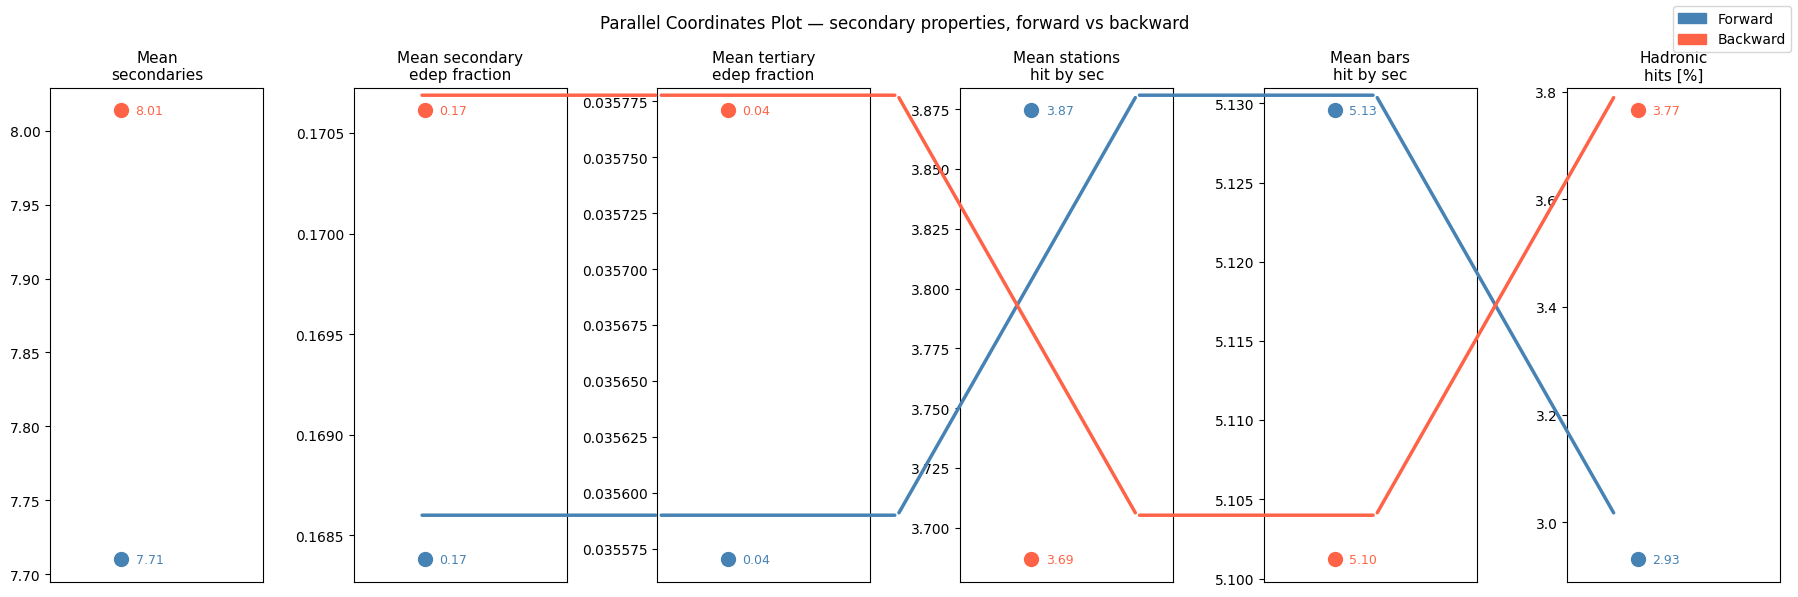

In [305]:
summary_sec = pd.DataFrame({
    "direction":            ["forward", "backward"],
    "mean_n_sec":           [n_sec_forward.mean(),  n_sec_backward.mean()],
    "mean_sec_edep_frac":   [frac_forward["frac_secondary"].mean(),  
                             frac_backward["frac_secondary"].mean()],
    "mean_tert_edep_frac":  [frac_forward["frac_tertiary+"].mean(),  
                             frac_backward["frac_tertiary+"].mean()],
    "mean_sec_stations":    [
        hits_forward[hits_forward["parent_id"] > 0].groupby(["event", "station"]).ngroups / forward_events.nunique(),
        hits_backward[hits_backward["parent_id"] > 0].groupby(["event", "station"]).ngroups / backward_events.nunique(),
    ],
    "mean_sec_bars":        [
        hits_forward[hits_forward["parent_id"] > 0].groupby(["event", "bar"]).ngroups / forward_events.nunique(),
        hits_backward[hits_backward["parent_id"] > 0].groupby(["event", "bar"]).ngroups / backward_events.nunique(),
    ],
    "pct_hadronic":         [
        hits_forward[hits_forward["pdg"].isin(hadronic_pdgs)].shape[0] / len(hits_forward) * 100,
        hits_backward[hits_backward["pdg"].isin(hadronic_pdgs)].shape[0] / len(hits_backward) * 100,
    ],
})

print(summary_sec)

vars_sec = ["mean_n_sec", "mean_sec_edep_frac", "mean_tert_edep_frac",
            "mean_sec_stations", "mean_sec_bars", "pct_hadronic"]

labels_sec = ["Mean\nsecondaries", "Mean secondary\nedep fraction",
              "Mean tertiary\nedep fraction", "Mean stations\nhit by sec",
              "Mean bars\nhit by sec", "Hadronic\nhits [%]"]

fig, axes = plt.subplots(1, len(vars_sec), figsize=(18, 6), sharey=False)

for i, (ax, var, label) in enumerate(zip(axes, vars_sec, labels_sec)):
    for _, row in summary_sec.iterrows():
        ax.plot(0, row[var], color=colors[row["direction"]],
                marker="o", markersize=10)
        ax.annotate(f"{row[var]:.2f}",
                    xy=(0, row[var]),
                    xytext=(0.1, row[var]),
                    fontsize=9, color=colors[row["direction"]],
                    va="center")
    ax.set_xticks([])
    ax.set_title(label, fontsize=11)
    ax.set_xlim(-0.5, 1)

for _, row in summary_sec.iterrows():
    for i in range(len(vars_sec) - 1):
        y1 = row[vars_sec[i]]
        y2 = row[vars_sec[i + 1]]

        ax1 = axes[i]
        ax2 = axes[i + 1]

        def to_fig(ax, y):
            ylim = ax.get_ylim()
            pos  = ax.get_position()
            y_norm = (y - ylim[0]) / (ylim[1] - ylim[0])
            return pos.x1, pos.y0 + y_norm * pos.height

        fig.canvas.draw()
        x1_fig, y1_fig = to_fig(ax1, y1)
        x2_fig, y2_fig = to_fig(ax2, y2)

        line = mpatches.FancyArrowPatch(
            posA=(x1_fig, y1_fig),
            posB=(x2_fig, y2_fig),
            transform=fig.transFigure,
            arrowstyle="-",
            color=colors[row["direction"]],
            linewidth=2.5
        )
        fig.add_artist(line)

handles = [mpatches.Patch(color="steelblue", label="Forward"),
           mpatches.Patch(color="tomato",    label="Backward")]
fig.legend(handles=handles, loc="upper right")
fig.suptitle("Parallel Coordinates Plot — secondary properties, forward vs backward")
plt.tight_layout()
plt.show()

In [310]:
# ── 1. IDENTIFY NEAR-MISS EVENTS (exactly 5 planes triggered) ─────────────────

planes_per_event = (
    hit_df.groupby("event")["station"]
    .nunique()
    .reset_index()
    .rename(columns={"station": "n_planes"})
)

near_miss_ids   = planes_per_event.loc[planes_per_event["n_planes"] == 5, "event"]
full_trigger_ids = planes_per_event.loc[planes_per_event["n_planes"] == 6, "event"]

near_miss_hits = hit_df[hit_df["event"].isin(near_miss_ids)].copy()
full_hits      = hit_df[hit_df["event"].isin(full_trigger_ids)].copy()

print(f"Near-miss events (5 planes) : {near_miss_ids.nunique():>6,}")
print(f"Full-trigger events (6 planes): {full_trigger_ids.nunique():>6,}")
print(f"Near-miss fraction           : {near_miss_ids.nunique() / planes_per_event.shape[0]:.2%}")

Near-miss events (5 planes) :      0
Full-trigger events (6 planes):  1,547
Near-miss fraction           : 0.00%
